# Projet Forecasting Ventes Télécom

Ce projet a été réalisé dans le cadre d'un stage d'été chez **Ooredoo Tunisie**. Son objectif est de développer une solution intelligente capable d'analyser les données historiques des ventes et de prévoir les ventes futures à l'aide de techniques de Machine Learning et de séries temporelles.

## Plan

- **Partie I** — Analyse Exploratoire des Données (EDA)
- **Partie II** — Construction de modèles de prévision
- **Partie III** — Entraînement, Validation (80/20) et Évaluation des performances

---
# PARTIE I — Analyse Exploratoire des Données (EDA)

# Analyse Exploratoire des Données (EDA) — Ventes Ooredoo (2022–2025)

**Objectif** : examiner, nettoyer et visualiser le dataset synthétique de ventes journalières
(produit × région × date) afin de préparer un projet de **forecasting** (prévision des ventes).

Plan du notebook :
1. Chargement des données
2. Aperçu général (structure, types, doublons)
3. Analyse des valeurs manquantes
4. Nettoyage des données
5. Vérifications de cohérence métier
6. Statistiques descriptives
7. Détection des valeurs extrêmes (outliers)
8. Analyse temporelle globale (tendance)
9. Saisonnalité (hebdomadaire, mensuelle, Ramadan, Aïd, promotions)
10. Analyse par catégorie de produit et migration technologique
11. Analyse régionale
12. Corrélations entre variables numériques
13. Décomposition de série temporelle (tendance / saisonnalité / résidu)
14. ACF / PACF (préparation ARIMA/SARIMA)
15. Synthèse des insights et pistes pour la modélisation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 50)


## 1. Chargement des données

In [3]:
df = pd.read_csv("ooredoo_sales_synthetic_2022_2025.csv", parse_dates=["date"])
df.shape


(73050, 45)

In [3]:
df.head()


,date,year,month,week,day,day_name,weekend,quarter,region,governorate,city,sales_channel,customer_type,product_category,product_name,technology,offer_type,promotion,promotion_discount,campaign_name,unit_price,quantity_sold,revenue,payment_method,network_usage_level,stock_available,competitor_campaign,public_holiday,school_holiday,ramadan,eid,weather,temperature,unemployment_index,inflation_index,fuel_price,customer_satisfaction,complaints,churn_rate,active_users,previous_day_sales,previous_week_sales,moving_average_7,moving_average_30,target_sales_next_day
0,2022-01-01,2022,1,52,1,samedi,1,1,Centre Ouest,Kairouan,Kairouan,Boutique,Particulier,Mobile,Forfait 5 DT,4G,Prépayé,0,0.0,Aucune,5.073,38,192.774,Carte bancaire,Moyen,77.0,0,1,1,0,0,Ensoleillé,1.2,15.16,5.89,2.104,4.15,1.0,3.21,2347,NaN,NaN,NaN,NaN,39.0
1,2022-01-02,2022,1,52,2,dimanche,1,1,Centre Ouest,Kairouan,Kairouan,Boutique,Particulier,Mobile,Forfait 5 DT,4G,Prépayé,0,0.0,Aucune,4.993,39,194.727,Paiement en ligne,Faible,66.0,0,0,1,0,0,Pluvieux,6.1,15.40,6.04,2.097,4.23,0.0,3.38,2237,38.0,NaN,38.00,38.00,30.0
2,2022-01-03,2022,1,1,3,lundi,0,1,Centre Ouest,Kairouan,Kairouan,Boutique,Particulier,Mobile,Forfait 5 DT,4G,Prépayé,0,0.0,Aucune,4.987,30,149.610,Carte bancaire,Faible,46.0,0,0,0,0,0,Ensoleillé,4.9,15.25,6.00,2.088,4.59,0.0,2.33,2305,39.0,NaN,38.50,38.50,21.0
3,2022-01-04,2022,1,1,4,mardi,0,1,Centre Ouest,Kairouan,Kairouan,Application Mobile,Particulier,Mobile,Forfait 5 DT,4G,Prépayé,0,0.0,Aucune,4.944,21,103.824,Mobile Money,Moyen,49.0,0,0,0,0,0,Ensoleillé,3.6,15.28,5.97,2.107,3.70,2.0,2.88,2320,30.0,NaN,35.67,35.67,23.0
4,2022-01-05,2022,1,1,5,mercredi,0,1,Centre Ouest,Kairouan,Kairouan,Revendeur,Particulier,Mobile,Forfait 5 DT,4G,Prépayé,1,5.5,Eid Mubarik Offers,4.634,23,106.582,Espèces,Faible,41.0,0,0,0,0,0,Pluvieux,0.7,15.24,5.89,2.102,4.25,0.0,2.34,2344,21.0,NaN,32.00,32.00,25.0


## 2. Aperçu général

On vérifie la structure du dataset : types de colonnes, doublons, plage de dates.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 73050 entries, 0 to 73049
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   73050 non-null  datetime64[us]
 1   year                   73050 non-null  int64         
 2   month                  73050 non-null  int64         
 3   week                   73050 non-null  int64         
 4   day                    73050 non-null  int64         
 5   day_name               73050 non-null  str           
 6   weekend                73050 non-null  int64         
 7   quarter                73050 non-null  int64         
 8   region                 73050 non-null  str           
 9   governorate            73050 non-null  str           
 10  city                   73050 non-null  str           
 11  sales_channel          73050 non-null  str           
 12  customer_type          73050 non-null  str           
 13  product_cate

In [5]:
print("Période couverte :", df['date'].min(), "->", df['date'].max())
print("Nombre de doublons exacts :", df.duplicated().sum())
print("Nombre de combinaisons région/produit (séries) :",
      df[['region', 'product_name']].drop_duplicates().shape[0])
print("Catégories de produits :", df['product_category'].unique())
print("Régions :", df['region'].unique())


Période couverte : 2022-01-01 00:00:00 -> 2025-12-31 00:00:00


Nombre de doublons exacts : 0
Nombre de combinaisons région/produit (séries) : 43
Catégories de produits : <StringArray>
['Mobile', 'Data', 'Internet Fixe']
Length: 3, dtype: str
Régions : <StringArray>
['Centre Ouest',    'Sud Ouest',   'Centre Est',  'Grand Tunis',
     'Nord Est',   'Nord Ouest',      'Sud Est']
Length: 7, dtype: str


## 3. Analyse des valeurs manquantes

On identifie quelles colonnes contiennent des NaN et dans quelle proportion.
 certaines colonnes de séries temporelles (`previous_day_sales`,
`previous_week_sales`, `moving_average_7`, `moving_average_30`, `target_sales_next_day`)
ont des NaN **naturels** en début/fin de série (pas de "jour précédent" au tout premier jour).
Ce n'est pas une anomalie à corriger de la même façon que les autres colonnes.

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_summary = missing_summary[missing_summary["n_missing"] > 0]
missing_summary


,n_missing,pct_missing
weather,1136,1.56
network_usage_level,1114,1.52
stock_available,1111,1.52
campaign_name,1109,1.52
fuel_price,1088,1.49
temperature,1080,1.48
payment_method,1076,1.47
customer_satisfaction,1066,1.46
complaints,1064,1.46
unemployment_index,1044,1.43


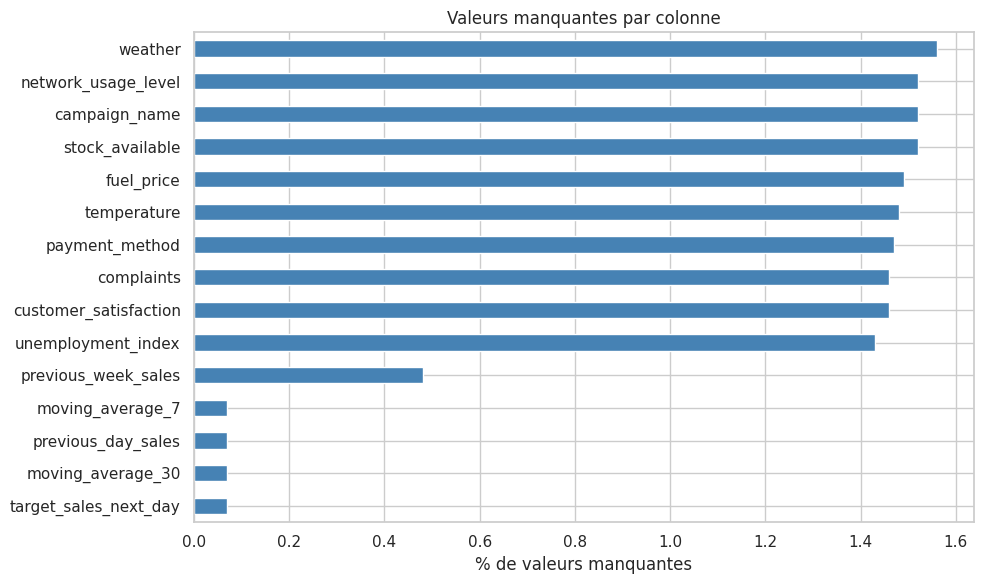

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_summary["pct_missing"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne")
plt.tight_layout()
plt.show()


## 4. Nettoyage des données

Stratégie de nettoyage :
- Les colonnes de **lags/moving averages** : les NaN de bord de série sont laissés tels quels
  (ils seront gérés au moment du feature engineering pour la modélisation, ex. `dropna` ou
  imputation par la moyenne de la série).
- Les colonnes **contextuelles** (`temperature`, `weather`, `customer_satisfaction`, `complaints`,
  `network_usage_level`, `campaign_name`, `payment_method`, `unemployment_index`, `fuel_price`,
  `stock_available`) : imputation simple (médiane pour le numérique, mode/"Inconnu" pour le
  catégoriel) car elles ne doivent jamais bloquer un modèle de forecasting.
- On ne touche **jamais** à `quantity_sold`, `unit_price`, `revenue` (colonnes clés, sans NaN
  injecté).

In [8]:
df_clean = df.copy()

num_impute_cols = ["temperature", "customer_satisfaction", "complaints",
                    "unemployment_index", "fuel_price", "stock_available"]
cat_impute_cols = ["weather", "network_usage_level", "campaign_name", "payment_method"]

for c in num_impute_cols:
    if c in df_clean.columns and df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_impute_cols:
    if c in df_clean.columns and df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

print("Valeurs manquantes restantes (hors colonnes de lag) :")
cols_lag = ["previous_day_sales", "previous_week_sales", "moving_average_7",
            "moving_average_30", "target_sales_next_day"]
print(df_clean.drop(columns=cols_lag).isna().sum().sum())


Valeurs manquantes restantes (hors colonnes de lag) :
0


In [9]:
# Tri chronologique par série (région + produit) : indispensable pour le forecasting
df_clean = df_clean.sort_values(["region", "product_name", "date"]).reset_index(drop=True)
df_clean.head(3)


,date,year,month,week,day,day_name,weekend,quarter,region,governorate,city,sales_channel,customer_type,product_category,product_name,technology,offer_type,promotion,promotion_discount,campaign_name,unit_price,quantity_sold,revenue,payment_method,network_usage_level,stock_available,competitor_campaign,public_holiday,school_holiday,ramadan,eid,weather,temperature,unemployment_index,inflation_index,fuel_price,customer_satisfaction,complaints,churn_rate,active_users,previous_day_sales,previous_week_sales,moving_average_7,moving_average_30,target_sales_next_day
0,2022-01-01,2022,1,52,1,samedi,1,1,Centre Est,Sfax,Sfax,Boutique,Particulier,Data,10 Go,4G,Prépayé,0,0.0,Aucune,12.004,53,636.212,Carte bancaire,Faible,129.0,0,1,1,0,0,Nuageux,7.4,15.16,5.89,2.104,3.92,1.0,3.53,1962,NaN,NaN,NaN,NaN,47.0
1,2022-01-02,2022,1,52,2,dimanche,1,1,Centre Est,Sfax,Sfax,Revendeur,Particulier,Data,10 Go,4G,Prépayé,0,0.0,Aucune,11.896,47,559.112,Espèces,Faible,109.0,0,0,1,0,0,Pluvieux,6.6,15.40,6.04,2.097,4.37,0.0,3.16,1948,53.0,NaN,53.0,53.0,56.0
2,2022-01-03,2022,1,1,3,lundi,0,1,Centre Est,Sfax,Sfax,Revendeur,Particulier,Data,10 Go,4G,Postpayé,1,24.0,Nouvel An Digital,9.221,56,516.376,Mobile Money,Faible,93.0,0,0,0,0,0,Pluvieux,8.8,15.25,6.00,2.088,4.42,0.0,2.58,1974,47.0,NaN,50.0,50.0,23.0


## 5. Vérifications de cohérence métier

On vérifie qu'il n'y a aucune incohérence mathématique ou logique dans les données.

In [10]:
# revenue doit toujours être égal à unit_price * quantity_sold
ecart = (df_clean["revenue"] - df_clean["unit_price"] * df_clean["quantity_sold"]).abs()
print("Écart max entre revenue et unit_price*quantity_sold :", ecart.max())

# quantity_sold et revenue doivent être positifs ou nuls
print("quantity_sold négatif :", (df_clean['quantity_sold'] < 0).sum())
print("revenue négatif :", (df_clean['revenue'] < 0).sum())
print("unit_price négatif ou nul :", (df_clean['unit_price'] <= 0).sum())

# cohérence promotion / discount
incoherent_promo = df_clean[(df_clean["promotion"] == 0) & (df_clean["promotion_discount"] > 0)]
print("Lignes incohérentes promotion=0 mais discount>0 :", len(incoherent_promo))


Écart max entre revenue et unit_price*quantity_sold : 3.637978807091713e-12
quantity_sold négatif : 0
revenue négatif : 0
unit_price négatif ou nul : 0
Lignes incohérentes promotion=0 mais discount>0 : 0


## 6. Statistiques descriptives

In [11]:
df_clean[["unit_price", "quantity_sold", "revenue", "temperature",
          "customer_satisfaction", "churn_rate", "active_users"]].describe().T


,count,mean,std,min,25%,50%,75%,max
unit_price,73050.0,34.137525,25.242446,3.298,11.28925,29.7770,51.16625,117.998
quantity_sold,73050.0,35.904230,38.793483,0.000,11.00000,24.0000,51.00000,3178.000
revenue,73050.0,863.741402,980.894323,0.000,285.54800,549.6805,1096.99250,33376.788
temperature,73050.0,17.625422,8.889556,-3.100,9.60000,17.7000,25.60000,40.100
customer_satisfaction,73050.0,4.159120,0.315023,2.770,3.95000,4.1600,4.37000,5.000
churn_rate,73050.0,3.005808,0.532649,1.230,2.65000,2.9600,3.29000,5.710
active_users,73050.0,2310.866283,648.809509,672.000,1848.00000,2314.0000,2771.00000,4485.000


In [12]:
df_clean["product_category"].value_counts(normalize=True).mul(100).round(1)


product_category
Mobile           50.0
Data             30.0
Internet Fixe    20.0
Name: proportion, dtype: float64

## 7. Détection des valeurs extrêmes (outliers)

Le dataset contient volontairement quelques ventes "flash" exceptionnelles (<1% des lignes).
On les visualise avec des boxplots et la méthode IQR.

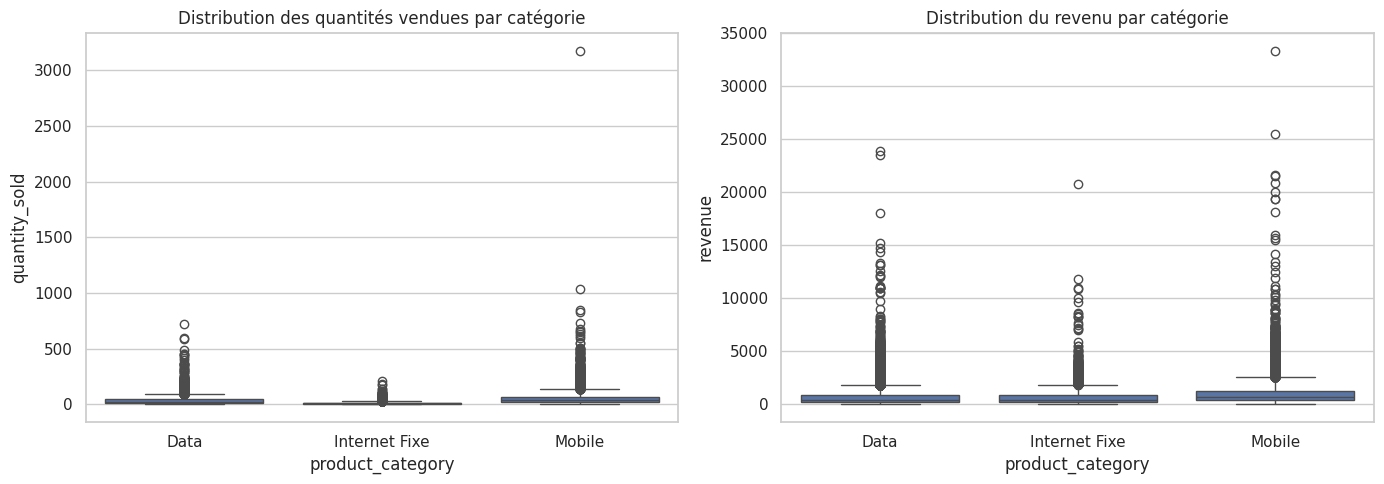

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x="product_category", y="quantity_sold", ax=axes[0])
axes[0].set_title("Distribution des quantités vendues par catégorie")
sns.boxplot(data=df_clean, x="product_category", y="revenue", ax=axes[1])
axes[1].set_title("Distribution du revenu par catégorie")
plt.tight_layout()
plt.show()


In [14]:
Q1 = df_clean["quantity_sold"].quantile(0.25)
Q3 = df_clean["quantity_sold"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_clean[(df_clean["quantity_sold"] < lower) | (df_clean["quantity_sold"] > upper)]
print(f"Bornes IQR : [{lower:.1f}, {upper:.1f}]")
print(f"Nombre de valeurs extrêmes détectées : {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")
outliers[["date", "region", "product_name", "quantity_sold", "promotion", "eid"]].sort_values(
    "quantity_sold", ascending=False).head(10)


Bornes IQR : [-49.0, 111.0]
Nombre de valeurs extrêmes détectées : 2725 (3.73%)


,date,region,product_name,quantity_sold,promotion,eid
35902,2025-06-07,Grand Tunis,Forfait 10 DT,3178,1,1
34279,2023-12-14,Grand Tunis,Forfait 10 DT,1037,0,0
35674,2025-03-23,Grand Tunis,Forfait 10 DT,846,0,0
34186,2023-11-13,Grand Tunis,Forfait 10 DT,831,0,0
13933,2023-01-28,Centre Est,Forfait 5 DT,728,0,0
27656,2023-11-11,Grand Tunis,5 Go,720,0,0
33433,2023-03-07,Grand Tunis,Forfait 10 DT,677,0,0
13480,2022-06-15,Centre Est,Forfait 5 DT,657,0,0
14649,2024-01-21,Centre Est,Forfait 5 DT,651,1,0
32398,2022-03-27,Grand Tunis,Forfait 10 DT,629,0,0


## 8. Analyse temporelle globale (tendance)

On agrège les ventes de toutes les séries pour obtenir une vue macro de l'évolution
sur les 4 années — utile pour repérer la tendance générale du marché.

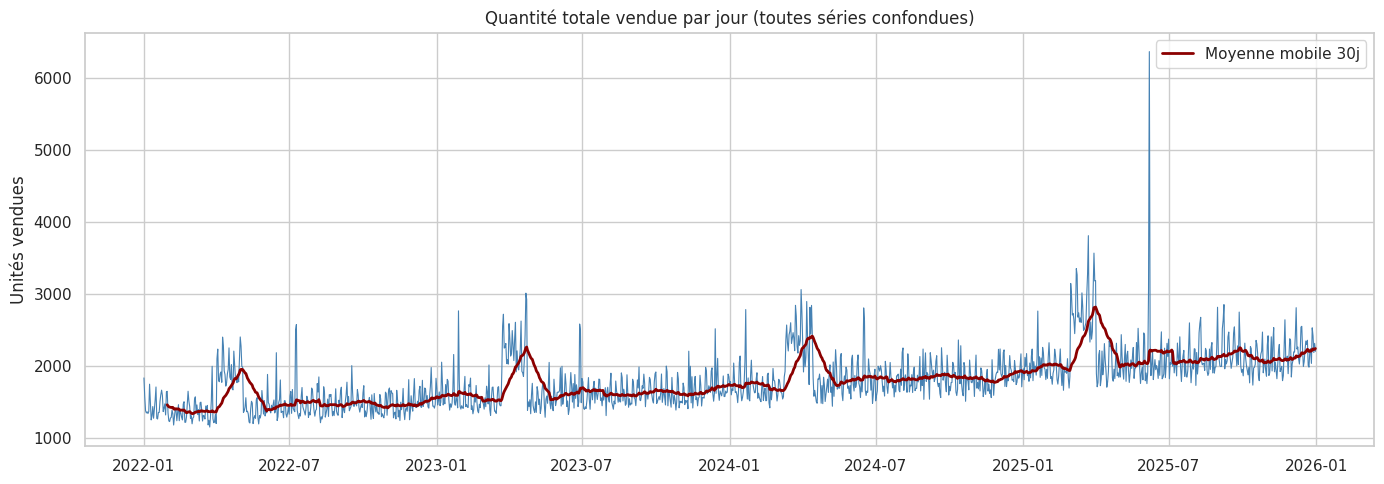

In [15]:
daily_global = df_clean.groupby("date").agg(
    total_quantity=("quantity_sold", "sum"),
    total_revenue=("revenue", "sum")
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_global["date"], daily_global["total_quantity"], color="steelblue", linewidth=0.8)
ax.plot(daily_global["date"], daily_global["total_quantity"].rolling(30).mean(),
        color="darkred", linewidth=2, label="Moyenne mobile 30j")
ax.set_title("Quantité totale vendue par jour (toutes séries confondues)")
ax.set_ylabel("Unités vendues")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
yearly = df_clean.groupby("year").agg(
    total_quantity=("quantity_sold", "sum"),
    total_revenue=("revenue", "sum")
)
yearly["croissance_qty_%"] = yearly["total_quantity"].pct_change().mul(100).round(1)
yearly


,total_quantity,total_revenue,croissance_qty_%
year,,,
2022,545436,1.101065e+07,NaN
2023,609543,1.356721e+07,11.8
2024,680800,1.689229e+07,11.7
2025,787025,2.162617e+07,15.6


## 9. Saisonnalité

### 9.1 Effet weekend

In [17]:
weekend_effect = df_clean.groupby(["product_category", "weekend"])["quantity_sold"].mean().unstack()
weekend_effect.columns = ["Semaine", "Weekend"]
weekend_effect


,Semaine,Weekend
product_category,,
Data,31.896900,38.145295
Internet Fixe,11.189549,10.372010
Mobile,44.687095,53.524211


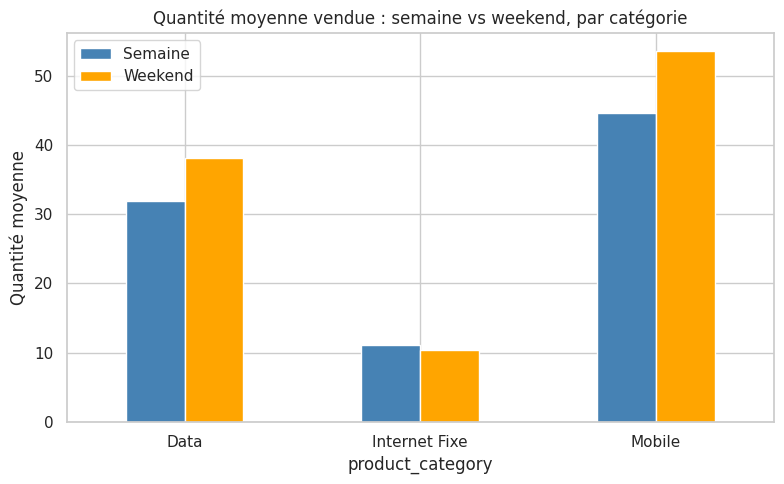

In [18]:
weekend_effect.plot(kind="bar", figsize=(8, 5), color=["steelblue", "orange"])
plt.title("Quantité moyenne vendue : semaine vs weekend, par catégorie")
plt.ylabel("Quantité moyenne")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 9.2 Effet mensuel

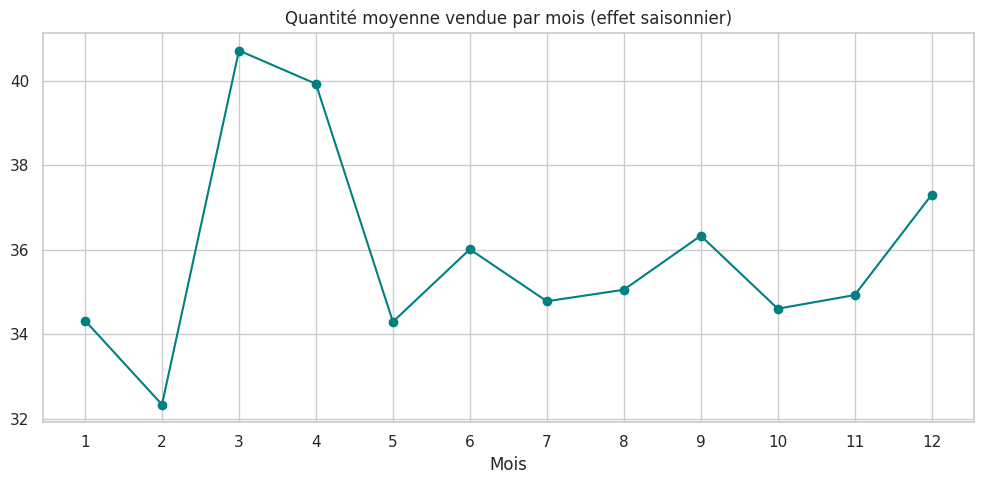

In [19]:
monthly_avg = df_clean.groupby("month")["quantity_sold"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg.plot(kind="line", marker="o", ax=ax, color="teal")
ax.set_xticks(range(1, 13))
ax.set_title("Quantité moyenne vendue par mois (effet saisonnier)")
ax.set_xlabel("Mois")
plt.tight_layout()
plt.show()


### 9.3 Effet Ramadan / Aïd / promotions

In [20]:
effects = pd.DataFrame({
    "Ramadan": df_clean.groupby("ramadan")["quantity_sold"].mean(),
    "Aïd": df_clean.groupby("eid")["quantity_sold"].mean(),
    "Promotion": df_clean.groupby("promotion")["quantity_sold"].mean(),
    "Vacances scolaires": df_clean.groupby("school_holiday")["quantity_sold"].mean(),
}).T
effects.columns = ["Non", "Oui"]
effects["hausse_%"] = ((effects["Oui"] / effects["Non"]) - 1).mul(100).round(1)
effects


,Non,Oui,hausse_%
Ramadan,34.966830,46.672308,33.5
Aïd,35.601499,57.716000,62.1
Promotion,33.994505,47.115783,38.6
Vacances scolaires,36.025486,35.687405,-0.9


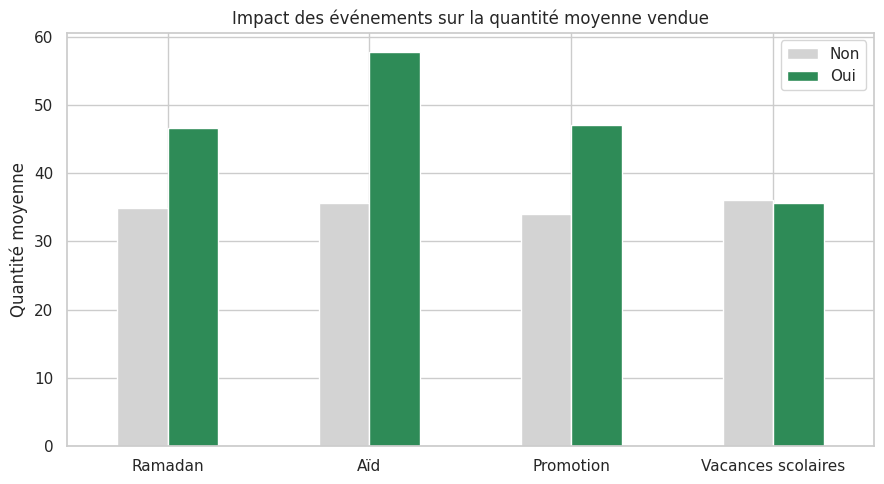

In [21]:
effects[["Non", "Oui"]].plot(kind="bar", figsize=(9, 5), color=["lightgrey", "seagreen"])
plt.title("Impact des événements sur la quantité moyenne vendue")
plt.ylabel("Quantité moyenne")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Analyse par catégorie de produit et migration technologique

On vérifie les hypothèses métier : Mobile reste le plus vendu, le 5G progresse,
le xDSL décline au profit de la Fibre.

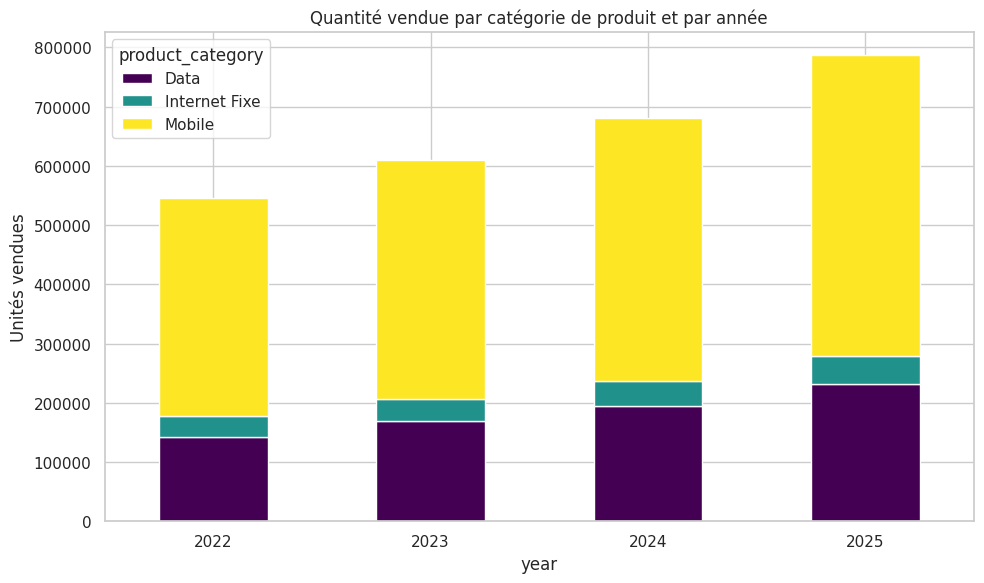

In [22]:
cat_yearly = df_clean.groupby(["year", "product_category"])["quantity_sold"].sum().unstack()
cat_yearly.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Quantité vendue par catégorie de produit et par année")
plt.ylabel("Unités vendues")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [23]:
tech_share = df_clean.groupby(["year", "technology"])["quantity_sold"].sum().unstack().fillna(0)
tech_share_pct = tech_share.div(tech_share.sum(axis=1), axis=0).mul(100)
tech_share_pct


technology,4G,5G,Fibre,xDSL
year,,,,
2022,85.547525,8.099392,3.566138,2.786945
2023,77.862431,15.938498,4.223820,1.975250
2024,69.323002,24.643361,4.755288,1.278349
2025,60.426924,33.658778,5.032877,0.881421


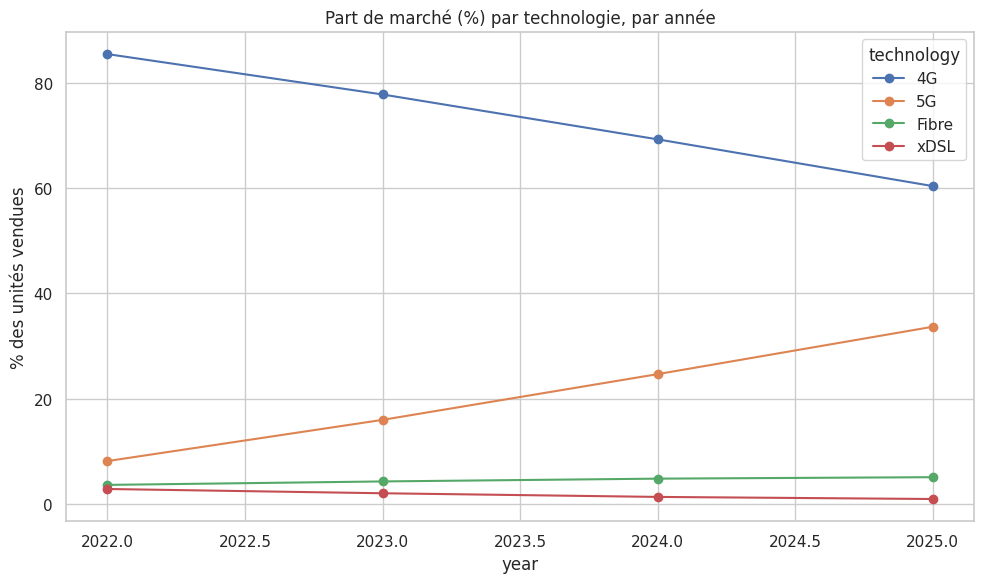

In [24]:
tech_share_pct.plot(kind="line", marker="o", figsize=(10, 6))
plt.title("Part de marché (%) par technologie, par année")
plt.ylabel("% des unités vendues")
plt.tight_layout()
plt.show()


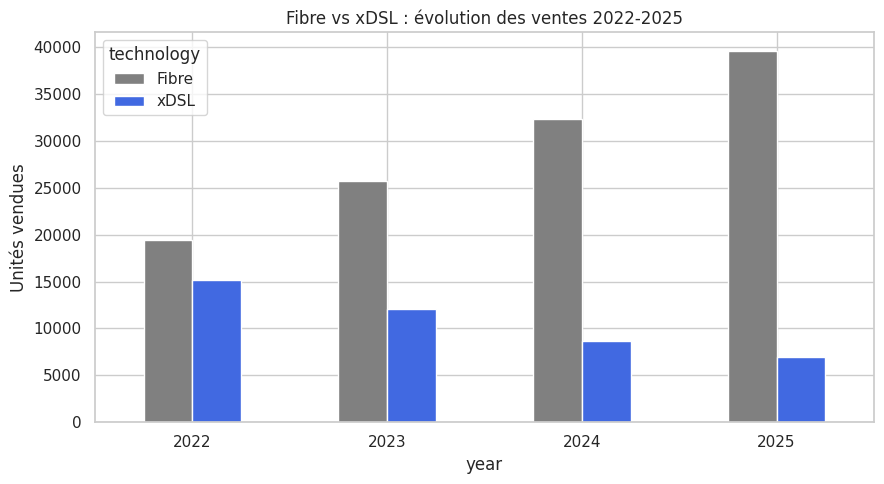

In [25]:
# Zoom xDSL vs Fibre uniquement
internet_tech = df_clean[df_clean["product_category"] == "Internet Fixe"]
fibre_xdsl = internet_tech.groupby(["year", "technology"])["quantity_sold"].sum().unstack().fillna(0)
fibre_xdsl.plot(kind="bar", figsize=(9, 5), color=["gray", "royalblue"])
plt.title("Fibre vs xDSL : évolution des ventes 2022-2025")
plt.ylabel("Unités vendues")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Analyse régionale

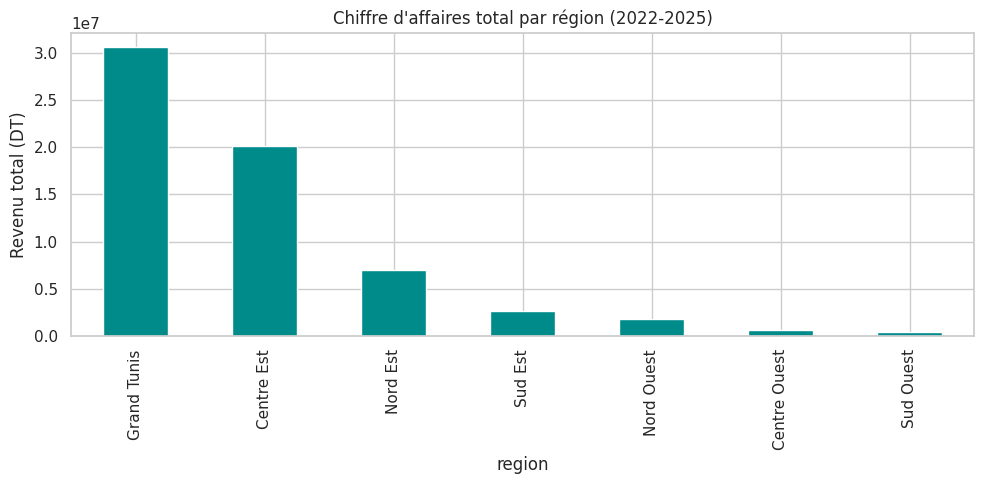

In [26]:
region_revenue = df_clean.groupby("region")["revenue"].sum().sort_values(ascending=False)
region_revenue.plot(kind="bar", figsize=(10, 5), color="darkcyan")
plt.title("Chiffre d'affaires total par région (2022-2025)")
plt.ylabel("Revenu total (DT)")
plt.tight_layout()
plt.show()


In [27]:
top_governorates = df_clean.groupby("governorate")["revenue"].sum().sort_values(ascending=False).head(10)
top_governorates


governorate
Tunis        1.497230e+07
Sfax         1.277785e+07
Ariana       7.703391e+06
Sousse       5.934528e+06
Nabeul       5.412820e+06
Manouba      3.955419e+06
Ben Arous    3.932755e+06
Médenine     1.570465e+06
Zaghouan     1.568017e+06
Monastir     1.392738e+06
Name: revenue, dtype: float64

## 12. Corrélations entre variables numériques

Utile pour repérer les features potentiellement redondantes ou fortement liées à la cible
avant de construire un modèle (Random Forest, XGBoost, LightGBM...).

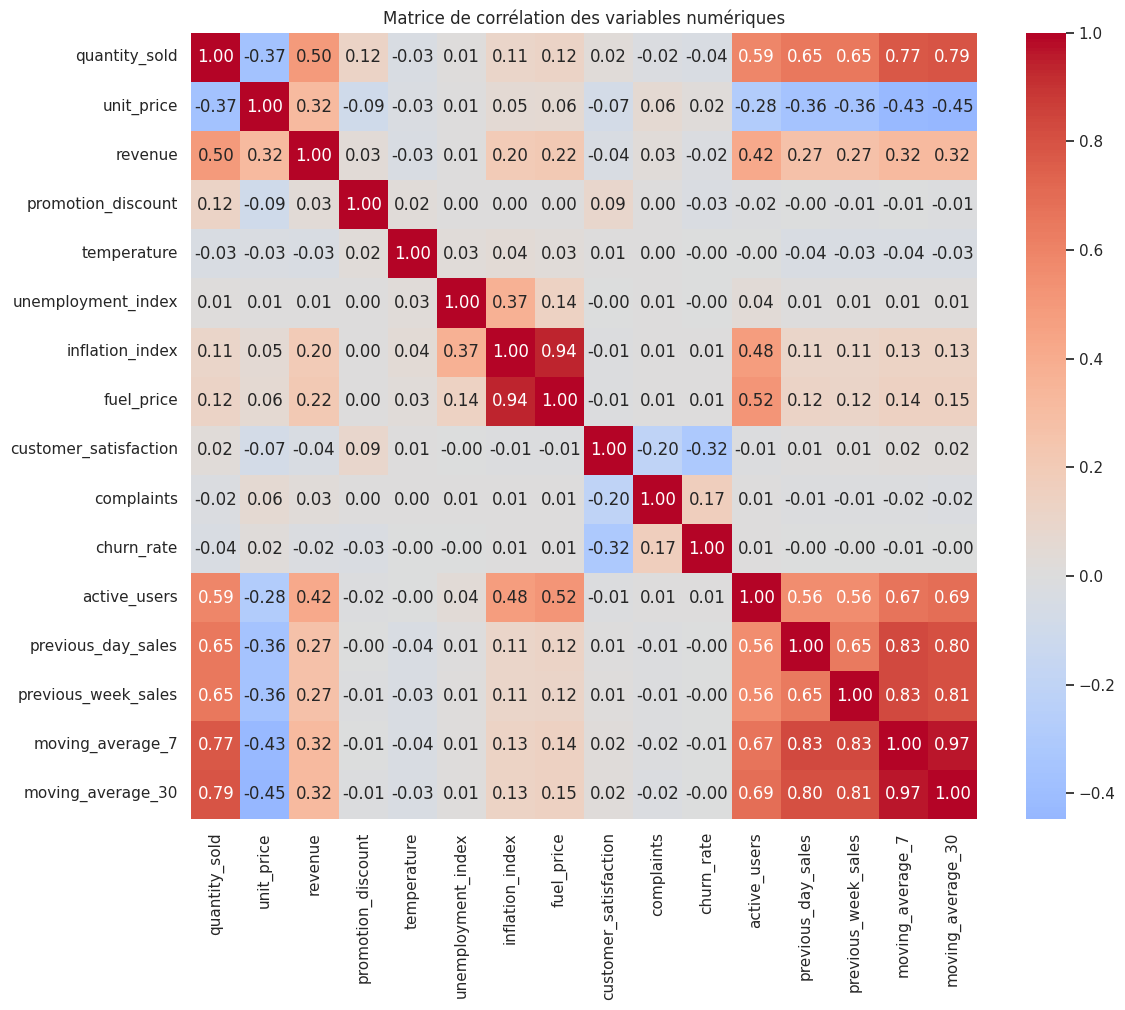

In [28]:
num_cols = ["quantity_sold", "unit_price", "revenue", "promotion_discount",
            "temperature", "unemployment_index", "inflation_index", "fuel_price",
            "customer_satisfaction", "complaints", "churn_rate", "active_users",
            "previous_day_sales", "previous_week_sales", "moving_average_7", "moving_average_30"]

corr = df_clean[num_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()


## 13. Décomposition de série temporelle (tendance / saisonnalité / résidu)

On étudie ici une série précise pour illustrer la décomposition classique utilisée en
ARIMA/SARIMA/Prophet : le produit **Forfait Illimité** dans la région **Grand Tunis**
(à adapter selon les séries disponibles dans le dataset).

Série sélectionnée : région = Grand Tunis | produit = Forfait 10 DT | n = 4383 jours


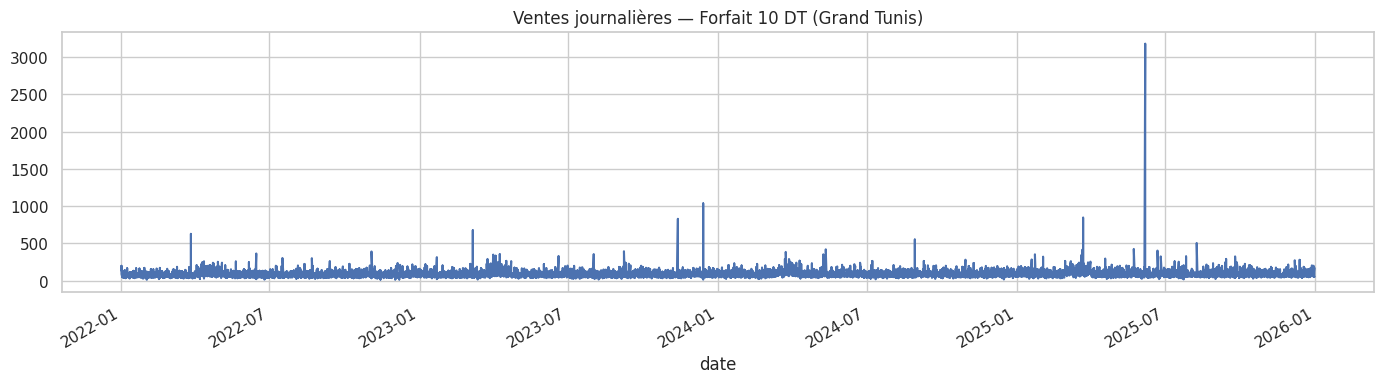

In [29]:
# Sélection automatique d'une série représentative bien peuplée (Mobile, région la plus vendeuse)
candidates = df_clean[df_clean["product_category"] == "Mobile"]
best_region = candidates.groupby("region")["quantity_sold"].sum().idxmax()
best_product = candidates[candidates["region"] == best_region] \
    .groupby("product_name")["quantity_sold"].sum().idxmax()

serie = df_clean[(df_clean["region"] == best_region) & (df_clean["product_name"] == best_product)] \
    .sort_values("date").set_index("date")["quantity_sold"]

print(f"Série sélectionnée : région = {best_region} | produit = {best_product} | n = {len(serie)} jours")
serie.plot(figsize=(14, 4), title=f"Ventes journalières — {best_product} ({best_region})")
plt.tight_layout()
plt.show()


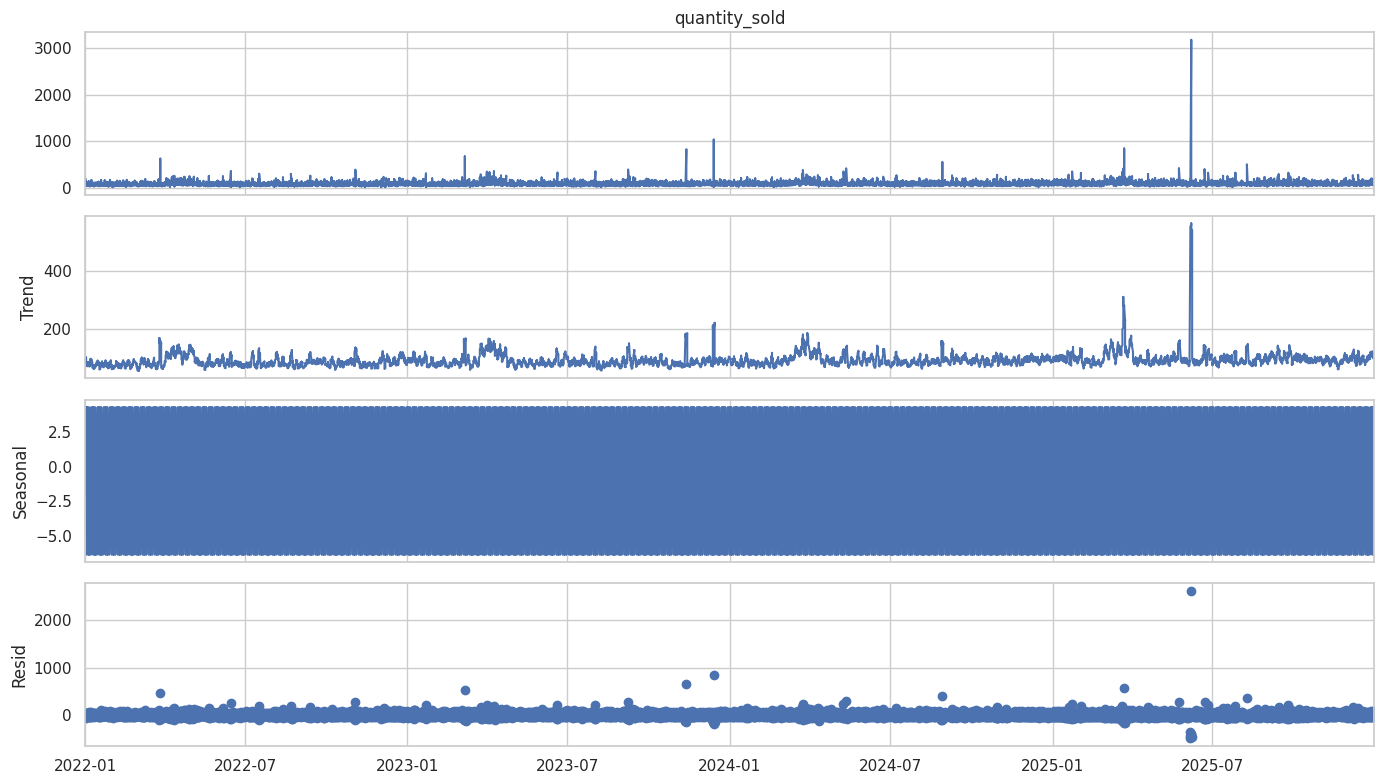

In [30]:
decomposition = seasonal_decompose(serie, model="additive", period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()


## 14. ACF / PACF (préparation ARIMA / SARIMA)

Ces graphiques aident à identifier les ordres p, d, q (et P, D, Q saisonniers)
pour un modèle ARIMA/SARIMA sur cette série.

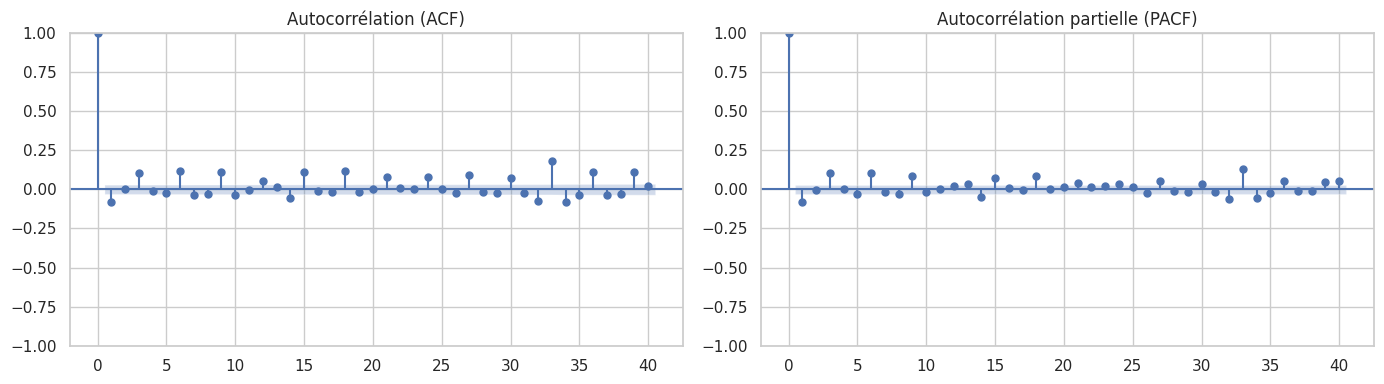

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie, lags=40, ax=axes[0])
axes[0].set_title("Autocorrélation (ACF)")
plot_pacf(serie, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Autocorrélation partielle (PACF)")
plt.tight_layout()
plt.show()


## 15. Synthèse des insights

**Constats principaux de l'EDA :**

- Le dataset est propre : aucune incohérence mathématique (`revenue = unit_price × quantity_sold`),
  pas de doublons, valeurs manquantes limitées et concentrées sur des colonnes secondaires.
- **Tendance** : croissance régulière du volume de ventes total entre 2022 et 2025.
- **Saisonnalité hebdomadaire** : les ventes Mobile/Data sont plus fortes le weekend, l'inverse
  pour l'Internet Fixe (usage professionnel plus présent en semaine).
- **Saisonnalité événementielle** : Ramadan et Aïd génèrent des pics de ventes nets, les
  promotions ont un effet positif mesurable.
- **Migration technologique confirmée** : part du 5G en hausse continue, xDSL en déclin au
  profit de la Fibre.
- **Mobile reste la catégorie dominante** en volume sur toute la période.
- **Disparités régionales fortes** : Tunis, Sfax et Sousse concentrent l'essentiel du chiffre
  d'affaires.
- La décomposition de série montre une composante saisonnière hebdomadaire claire et une
  tendance globalement croissante, cohérente avec un modèle SARIMA(p,d,q)(P,D,Q,7) ou un
  modèle Prophet avec saisonnalité hebdomadaire + événements (Ramadan, Aïd, jours fériés) en
  variables exogènes (`add_regressor`).

**Pistes pour la suite (modélisation) :**
1. Pour ARIMA/SARIMA/Prophet : travailler sur une série agrégée ou par série individuelle
   (region + product_name), utiliser `moving_average_7/30`, `ramadan`, `eid`, `promotion`
   comme régresseurs exogènes.
2. Pour Random Forest / XGBoost / LightGBM : utiliser toutes les features encodées
   (one-hot pour les catégorielles), plus les lags (`previous_day_sales`,
   `previous_week_sales`, moyennes mobiles) comme variables explicatives, cible = `quantity_sold`
   ou `target_sales_next_day`.
3. Pour LSTM/GRU/Transformer : construire des séquences par série (region + product_name)
   triées par date, normaliser les features numériques, encoder les catégorielles.
4. Gérer les NaN de bord de série (premiers/derniers jours) avant l'entraînement — soit en
   les supprimant, soit en les imputant selon le modèle choisi.


---
# PARTIE II — Construction de modèles de prévision

# Construction de modèles de prévision — Ventes Ooredoo (2022–2025)

Ce notebook construit et compare plusieurs familles de modèles de forecasting sur le dataset
synthétique `ooredoo_sales_synthetic_2022_2025.csv` :

- **Modèles classiques** (série agrégée nationale, univariés) : ARIMA, SARIMA, Holt-Winters, Prophet
- **Modèles Machine Learning** (données tabulaires, tout le panel région × produit) : Random Forest, XGBoost, LightGBM
- **Modèles Deep Learning** (séquences par série région × produit) : LSTM, GRU, Transformer
- **Modèles génératifs / foundation models pour séries temporelles** : TimesFM, Chronos, Moirai, Lag-Llama

**Important sur la comparabilité** : les modèles classiques prévoient le **volume total national
quotidien** (une seule série agrégée), alors que les modèles ML/DL prévoient les ventes **au niveau
fin région × produit** (50 séries). Les erreurs (RMSE/MAE) ne sont donc pas directement comparables
en valeur absolue entre les deux familles — on regarde plutôt le **MAPE** (%) et on compare les
modèles **au sein de chaque famille**.

**Découpage train/test** : la période de test est fixée aux **90 derniers jours** du dataset
(à partir du 2025-10-02) pour toutes les approches, afin de garder un cadre d'évaluation cohérent.


In [32]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)
pd.set_option("display.max_columns", 50)

SPLIT_DATE = pd.Timestamp("2025-10-02")   # début des 90 derniers jours (test)

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = []  # on stocke ici tous les résultats (nom, famille, RMSE, MAE, MAPE)


## 0. Chargement des données

In [33]:
df = pd.read_csv("ooredoo_sales_synthetic_2022_2025.csv", parse_dates=["date"])
df = df.sort_values(["region", "product_name", "date"]).reset_index(drop=True)
print(df.shape)
df.head(3)


(73050, 45)


,date,year,month,week,day,day_name,weekend,quarter,region,governorate,city,sales_channel,customer_type,product_category,product_name,technology,offer_type,promotion,promotion_discount,campaign_name,unit_price,quantity_sold,revenue,payment_method,network_usage_level,stock_available,competitor_campaign,public_holiday,school_holiday,ramadan,eid,weather,temperature,unemployment_index,inflation_index,fuel_price,customer_satisfaction,complaints,churn_rate,active_users,previous_day_sales,previous_week_sales,moving_average_7,moving_average_30,target_sales_next_day
0,2022-01-01,2022,1,52,1,samedi,1,1,Centre Est,Sfax,Sfax,Boutique,Particulier,Data,10 Go,4G,Prépayé,0,0.0,Aucune,12.004,53,636.212,Carte bancaire,Faible,129.0,0,1,1,0,0,Nuageux,7.4,15.16,5.89,2.104,3.92,1.0,3.53,1962,NaN,NaN,NaN,NaN,47.0
1,2022-01-02,2022,1,52,2,dimanche,1,1,Centre Est,Sfax,Sfax,Revendeur,Particulier,Data,10 Go,4G,Prépayé,0,0.0,Aucune,11.896,47,559.112,NaN,Faible,109.0,0,0,1,0,0,Pluvieux,6.6,15.40,6.04,2.097,4.37,0.0,3.16,1948,53.0,NaN,53.0,53.0,56.0
2,2022-01-03,2022,1,1,3,lundi,0,1,Centre Est,Sfax,Sfax,Revendeur,Particulier,Data,10 Go,4G,Postpayé,1,24.0,Nouvel An Digital,9.221,56,516.376,Mobile Money,Faible,93.0,0,0,0,0,0,Pluvieux,8.8,15.25,6.00,2.088,4.42,0.0,2.58,1974,47.0,NaN,50.0,50.0,23.0


---
# PARTIE A — Modèles classiques (série agrégée nationale)

On construit d'abord la série journalière du **volume total de ventes** (toutes séries
confondues), ainsi que quelques variables exogènes agrégées (Ramadan, Aïd, jour férié,
vacances scolaires, taux de promotion journalier) qui serviront de régresseurs pour Prophet.


Train : (1370, 6) | Test : (91, 6)


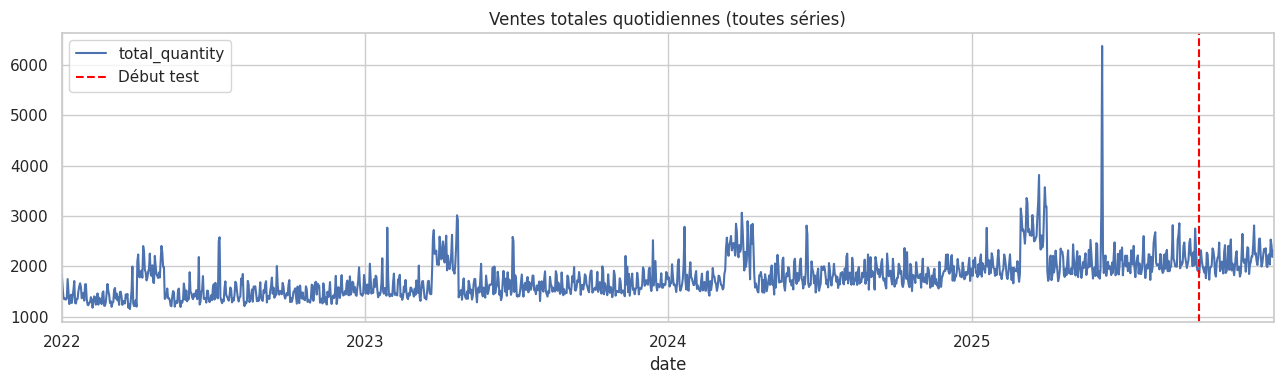

In [34]:
daily = df.groupby("date").agg(
    total_quantity=("quantity_sold", "sum"),
    ramadan=("ramadan", "max"),
    eid=("eid", "max"),
    public_holiday=("public_holiday", "max"),
    school_holiday=("school_holiday", "max"),
    promo_rate=("promotion", "mean"),
).reset_index()
daily = daily.set_index("date").asfreq("D")
daily[["ramadan", "eid", "public_holiday", "school_holiday"]] = \
    daily[["ramadan", "eid", "public_holiday", "school_holiday"]].fillna(0)
daily["promo_rate"] = daily["promo_rate"].fillna(daily["promo_rate"].mean())

train_daily = daily.loc[daily.index < SPLIT_DATE]
test_daily = daily.loc[daily.index >= SPLIT_DATE]
print("Train :", train_daily.shape, "| Test :", test_daily.shape)

daily["total_quantity"].plot(title="Ventes totales quotidiennes (toutes séries)", figsize=(13, 4))
plt.axvline(SPLIT_DATE, color="red", linestyle="--", label="Début test")
plt.legend()
plt.tight_layout()
plt.show()


### A.0 Test de stationnarité (ADF)

Un test ADF (Augmented Dickey-Fuller) permet de vérifier si la série est stationnaire, ce
qui guide le choix du paramètre de différenciation `d` pour ARIMA/SARIMA.

In [35]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_daily["total_quantity"])
print(f"Statistique ADF : {adf_result[0]:.3f}")
print(f"p-value : {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("=> Série stationnaire (on peut utiliser d=0 ou d=1 selon le contexte)")
else:
    print("=> Série non stationnaire => une différenciation (d=1) est nécessaire")


Statistique ADF : -3.706
p-value : 0.0040
=> Série stationnaire (on peut utiliser d=0 ou d=1 selon le contexte)


### A.1 ARIMA

                               SARIMAX Results                                
Dep. Variable:         total_quantity   No. Observations:                 1370
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -9545.974
Date:                Thu, 30 Jul 2026   AIC                          19101.948
Time:                        20:27:39   BIC                          19128.057
Sample:                    01-01-2022   HQIC                         19111.719
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
RMSE=217.8 | MAE=181.4 | MAPE=8.58%


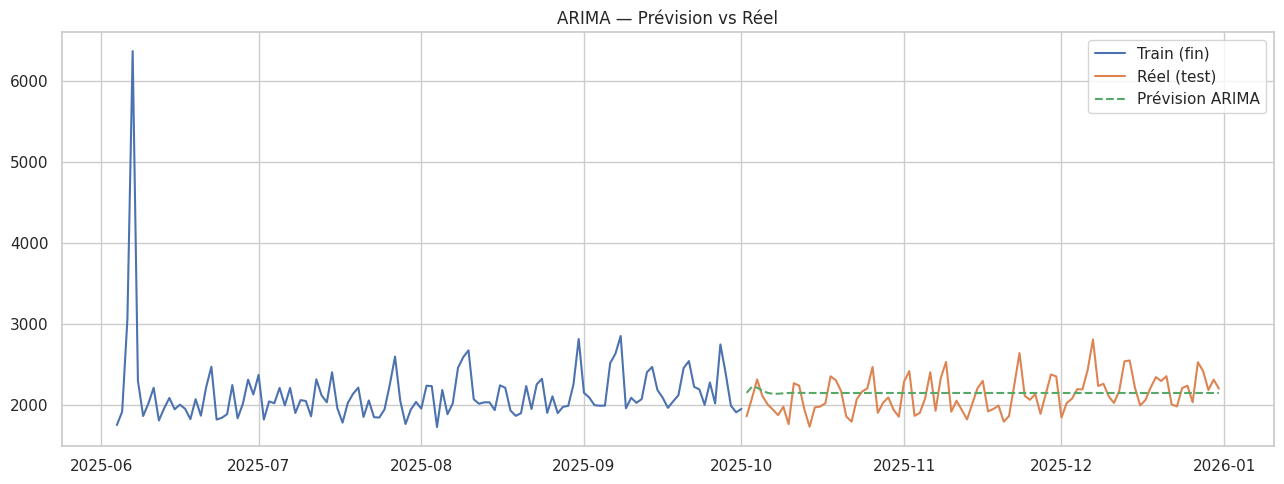

In [36]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train_daily["total_quantity"], order=(2, 1, 2)).fit()
print(arima_model.summary().tables[0])

arima_forecast = arima_model.forecast(steps=len(test_daily))
arima_forecast.index = test_daily.index

r, m, mp = rmse(test_daily["total_quantity"], arima_forecast), \
           mean_absolute_error(test_daily["total_quantity"], arima_forecast), \
           mape(test_daily["total_quantity"], arima_forecast)
results.append({"modele": "ARIMA(2,1,2)", "famille": "Classique (série agrégée)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.1f} | MAE={m:.1f} | MAPE={mp:.2f}%")

plt.plot(train_daily.index[-120:], train_daily["total_quantity"].iloc[-120:], label="Train (fin)")
plt.plot(test_daily.index, test_daily["total_quantity"], label="Réel (test)")
plt.plot(arima_forecast.index, arima_forecast, label="Prévision ARIMA", linestyle="--")
plt.legend(); plt.title("ARIMA — Prévision vs Réel"); plt.tight_layout(); plt.show()


### A.2 SARIMA (saisonnalité hebdomadaire, période=7)

RMSE=152.8 | MAE=127.4 | MAPE=6.15%


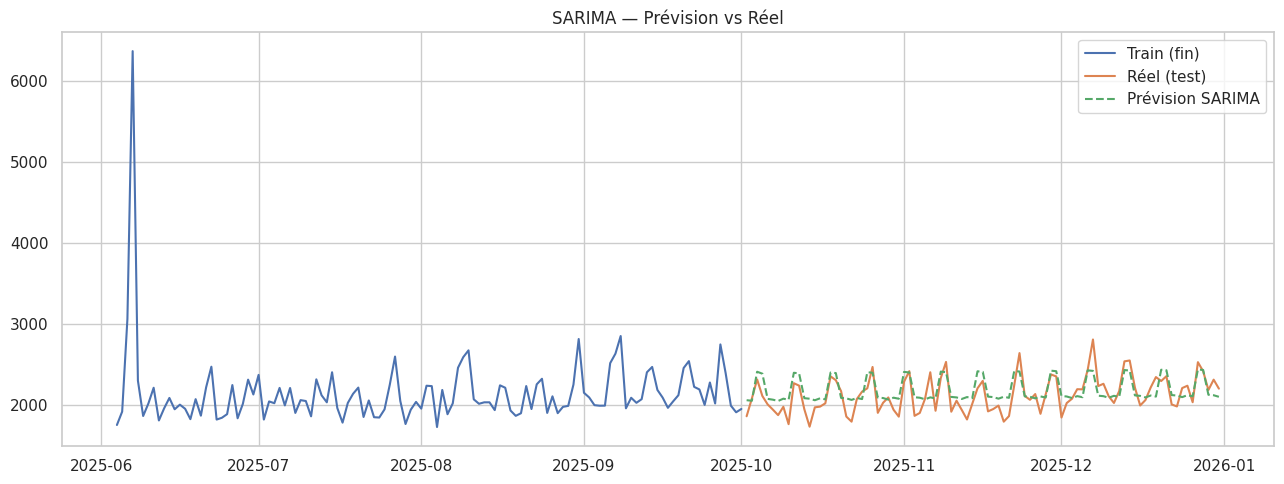

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_daily["total_quantity"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(test_daily))
sarima_forecast.index = test_daily.index

r, m, mp = rmse(test_daily["total_quantity"], sarima_forecast), \
           mean_absolute_error(test_daily["total_quantity"], sarima_forecast), \
           mape(test_daily["total_quantity"], sarima_forecast)
results.append({"modele": "SARIMA(1,1,1)(1,1,1,7)", "famille": "Classique (série agrégée)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.1f} | MAE={m:.1f} | MAPE={mp:.2f}%")

plt.plot(train_daily.index[-120:], train_daily["total_quantity"].iloc[-120:], label="Train (fin)")
plt.plot(test_daily.index, test_daily["total_quantity"], label="Réel (test)")
plt.plot(sarima_forecast.index, sarima_forecast, label="Prévision SARIMA", linestyle="--")
plt.legend(); plt.title("SARIMA — Prévision vs Réel"); plt.tight_layout(); plt.show()


### A.3 Holt-Winters (lissage exponentiel avec tendance et saisonnalité)

RMSE=145.4 | MAE=120.1 | MAPE=5.70%


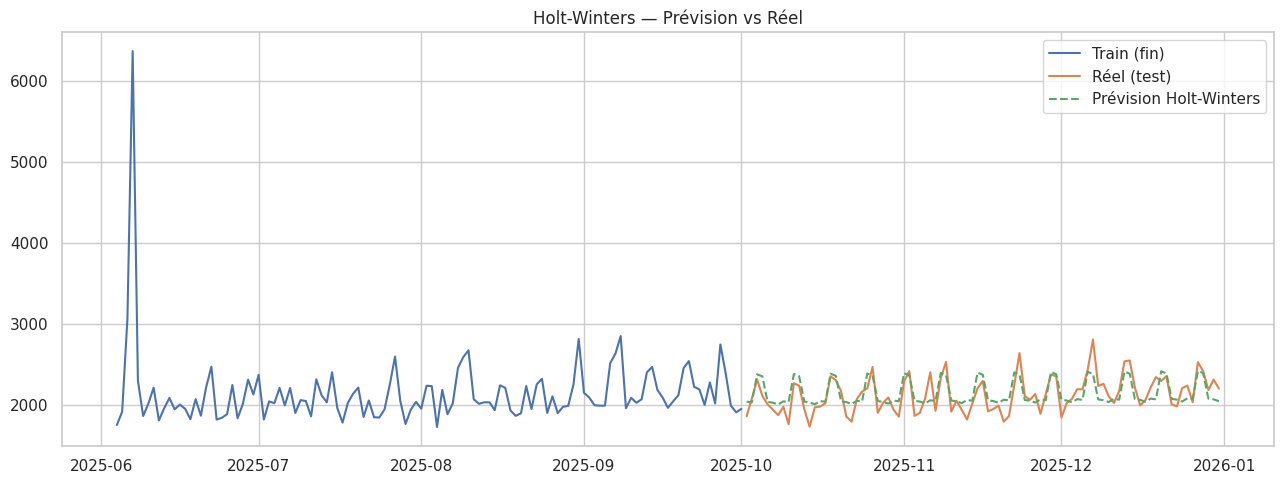

In [38]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train_daily["total_quantity"], trend="add", seasonal="add", seasonal_periods=7
).fit()

hw_forecast = hw_model.forecast(len(test_daily))
hw_forecast.index = test_daily.index

r, m, mp = rmse(test_daily["total_quantity"], hw_forecast), \
           mean_absolute_error(test_daily["total_quantity"], hw_forecast), \
           mape(test_daily["total_quantity"], hw_forecast)
results.append({"modele": "Holt-Winters", "famille": "Classique (série agrégée)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.1f} | MAE={m:.1f} | MAPE={mp:.2f}%")

plt.plot(train_daily.index[-120:], train_daily["total_quantity"].iloc[-120:], label="Train (fin)")
plt.plot(test_daily.index, test_daily["total_quantity"], label="Réel (test)")
plt.plot(hw_forecast.index, hw_forecast, label="Prévision Holt-Winters", linestyle="--")
plt.legend(); plt.title("Holt-Winters — Prévision vs Réel"); plt.tight_layout(); plt.show()


### A.4 Prophet

Prophet permet d'ajouter facilement des **régresseurs exogènes** : ici Ramadan, Aïd, jour
férié, vacances scolaires et taux de promotion journalier.

Importing plotly failed. Interactive plots will not work.


20:27:43 - cmdstanpy - INFO - Chain [1] start processing


20:27:44 - cmdstanpy - INFO - Chain [1] done processing


RMSE=138.5 | MAE=112.4 | MAPE=5.48%


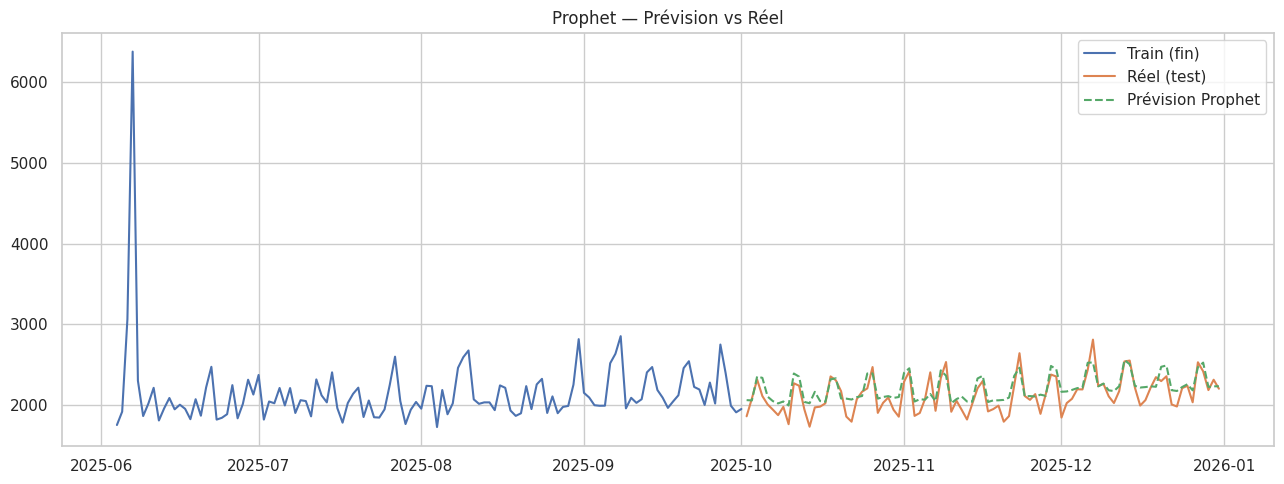

In [39]:
from prophet import Prophet

prophet_train = train_daily.reset_index().rename(columns={"date": "ds", "total_quantity": "y"})
prophet_test = test_daily.reset_index().rename(columns={"date": "ds", "total_quantity": "y"})

prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
for reg in ["ramadan", "eid", "public_holiday", "school_holiday", "promo_rate"]:
    prophet_model.add_regressor(reg)
prophet_model.fit(prophet_train)

future = prophet_test[["ds", "ramadan", "eid", "public_holiday", "school_holiday", "promo_rate"]]
prophet_forecast = prophet_model.predict(future)

r, m, mp = rmse(prophet_test["y"], prophet_forecast["yhat"]), \
           mean_absolute_error(prophet_test["y"], prophet_forecast["yhat"]), \
           mape(prophet_test["y"], prophet_forecast["yhat"])
results.append({"modele": "Prophet + régresseurs", "famille": "Classique (série agrégée)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.1f} | MAE={m:.1f} | MAPE={mp:.2f}%")

plt.plot(prophet_train["ds"].iloc[-120:], prophet_train["y"].iloc[-120:], label="Train (fin)")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Réel (test)")
plt.plot(prophet_test["ds"], prophet_forecast["yhat"], label="Prévision Prophet", linestyle="--")
plt.legend(); plt.title("Prophet — Prévision vs Réel"); plt.tight_layout(); plt.show()


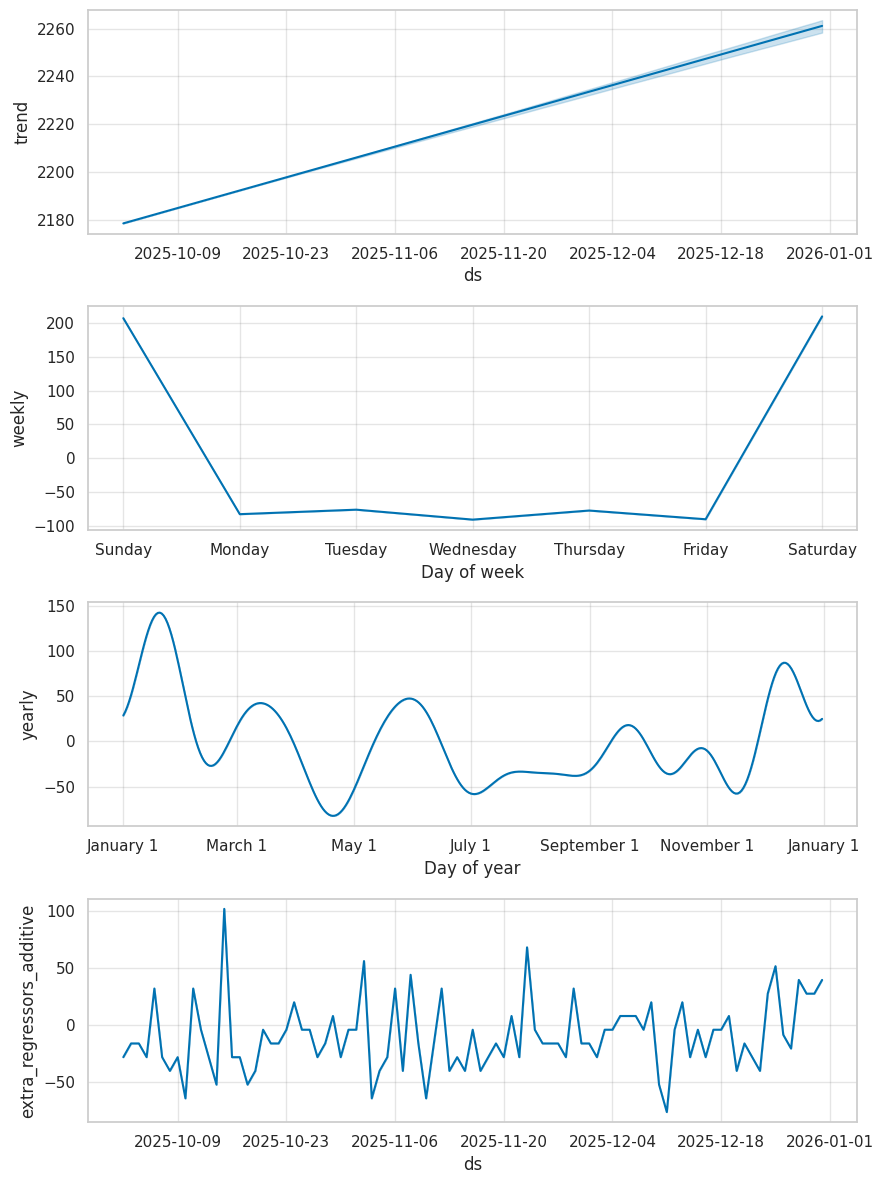

In [40]:
fig = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()


### A.5 Comparaison des modèles classiques

,RMSE,MAE,MAPE_%
modele,,,
"ARIMA(2,1,2)",217.820544,181.378868,8.584974
"SARIMA(1,1,1)(1,1,1,7)",152.810527,127.371795,6.152205
Holt-Winters,145.437767,120.061499,5.701039
Prophet + régresseurs,138.487169,112.351072,5.481251


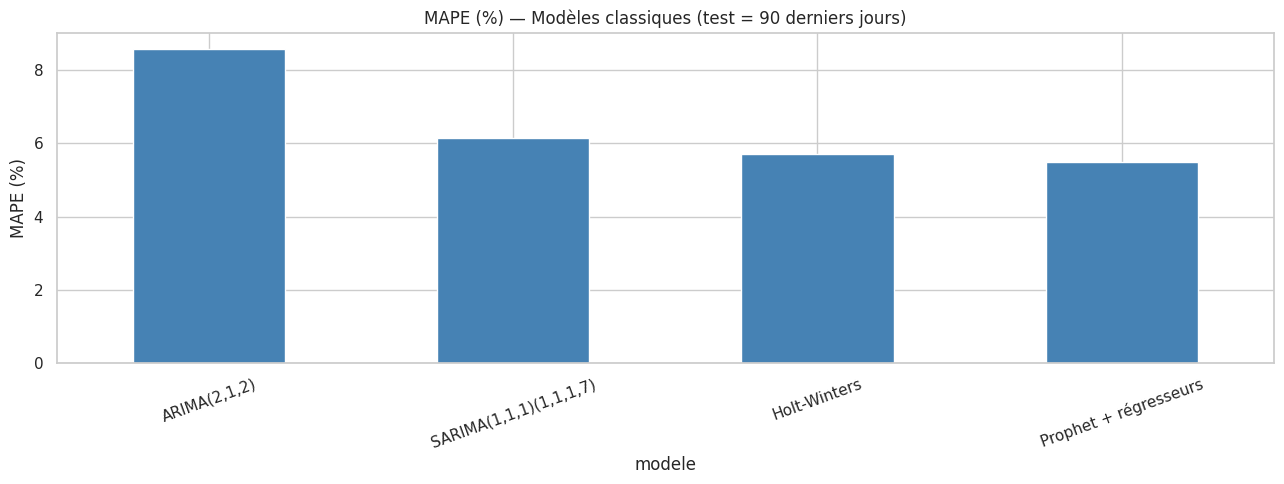

In [41]:
classic_results = pd.DataFrame([r for r in results if r["famille"] == "Classique (série agrégée)"])
classic_results = classic_results.set_index("modele")[["RMSE", "MAE", "MAPE_%"]]
display(classic_results)

classic_results["MAPE_%"].plot(kind="bar", color="steelblue", title="MAPE (%) — Modèles classiques (test = 90 derniers jours)")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


---
# PARTIE B — Modèles Machine Learning (tabulaire, panel complet)

Ici on travaille au niveau fin **région × produit × jour** (73 050 lignes). La cible est
`target_sales_next_day` (prévision à horizon 1 jour), les features incluent toutes les
variables contextuelles ainsi que les lags déjà présents dans le dataset
(`previous_day_sales`, `previous_week_sales`, `moving_average_7/30`).


In [42]:
cat_cols = ["region", "governorate", "city", "sales_channel", "customer_type",
            "product_category", "product_name", "technology", "offer_type",
            "payment_method", "network_usage_level", "weather", "campaign_name"]

df_ml = df.copy()
for c in cat_cols:
    df_ml[c] = df_ml[c].astype(str).fillna("Inconnu")
    df_ml[c + "_enc"] = LabelEncoder().fit_transform(df_ml[c])

feature_cols = [c + "_enc" for c in cat_cols] + [
    "year", "month", "week", "day", "weekend", "quarter", "promotion", "promotion_discount",
    "unit_price", "quantity_sold", "stock_available", "competitor_campaign", "public_holiday",
    "school_holiday", "ramadan", "eid", "temperature", "unemployment_index", "inflation_index",
    "fuel_price", "customer_satisfaction", "complaints", "churn_rate", "active_users",
    "previous_day_sales", "previous_week_sales", "moving_average_7", "moving_average_30",
]
target_col = "target_sales_next_day"

data_ml = df_ml.dropna(subset=[target_col] + feature_cols).copy()
print(f"Lignes conservées après suppression des NaN de bord de série : {len(data_ml)} / {len(df_ml)}")

train_ml = data_ml[data_ml["date"] < SPLIT_DATE]
test_ml = data_ml[data_ml["date"] >= SPLIT_DATE]
print("Train :", train_ml.shape, "| Test :", test_ml.shape)

X_train, y_train = train_ml[feature_cols], train_ml[target_col]
X_test, y_test = test_ml[feature_cols], test_ml[target_col]


Lignes conservées après suppression des NaN de bord de série : 66460 / 73050
Train : (62294, 58) | Test : (4166, 58)


### B.1 Random Forest

In [43]:
from sklearn.ensemble import RandomForestRegressor

t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=150, max_depth=12, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
print(f"Temps d'entraînement RF : {time.time()-t0:.1f}s")

rf_pred = rf_model.predict(X_test)
r, m, mp = rmse(y_test, rf_pred), mean_absolute_error(y_test, rf_pred), mape(y_test, rf_pred)
results.append({"modele": "Random Forest", "famille": "ML (panel complet)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.2f} | MAE={m:.2f} | MAPE={mp:.2f}%")


Temps d'entraînement RF : 92.1s
RMSE=20.82 | MAE=12.23 | MAPE=35.71%


### B.2 XGBoost

In [44]:
import xgboost as xgb

t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08,
                              subsample=0.9, colsample_bytree=0.9, n_jobs=-1, random_state=42)
xgb_model.fit(X_train, y_train)
print(f"Temps d'entraînement XGBoost : {time.time()-t0:.1f}s")

xgb_pred = xgb_model.predict(X_test)
r, m, mp = rmse(y_test, xgb_pred), mean_absolute_error(y_test, xgb_pred), mape(y_test, xgb_pred)
results.append({"modele": "XGBoost", "famille": "ML (panel complet)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.2f} | MAE={m:.2f} | MAPE={mp:.2f}%")


Temps d'entraînement XGBoost : 3.2s
RMSE=21.27 | MAE=12.48 | MAPE=35.29%


### B.3 LightGBM

In [45]:
import lightgbm as lgb

t0 = time.time()
lgb_model = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.08,
                               subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                               random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)
print(f"Temps d'entraînement LightGBM : {time.time()-t0:.1f}s")

lgb_pred = lgb_model.predict(X_test)
r, m, mp = rmse(y_test, lgb_pred), mean_absolute_error(y_test, lgb_pred), mape(y_test, lgb_pred)
results.append({"modele": "LightGBM", "famille": "ML (panel complet)", "RMSE": r, "MAE": m, "MAPE_%": mp})
print(f"RMSE={r:.2f} | MAE={m:.2f} | MAPE={mp:.2f}%")


Temps d'entraînement LightGBM : 2.4s
RMSE=19.43 | MAE=11.23 | MAPE=32.36%


### B.4 Importance des variables (XGBoost / LightGBM)

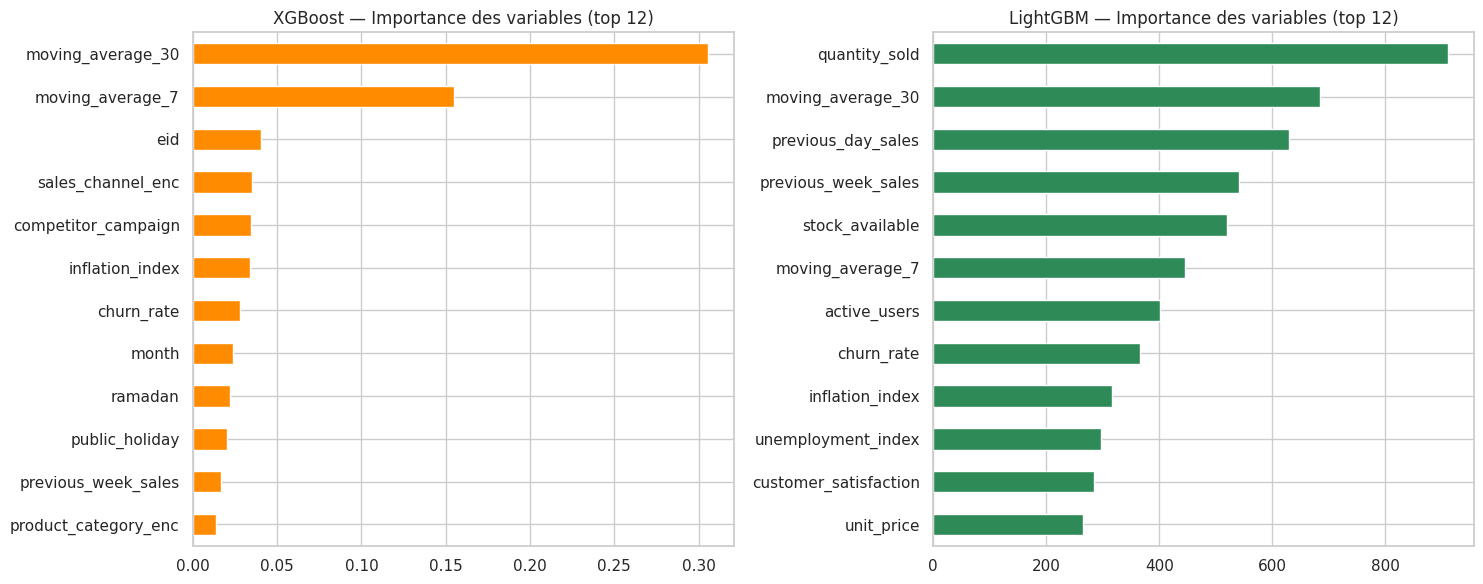

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(12)
imp_xgb.plot(kind="barh", ax=axes[0], color="darkorange")
axes[0].invert_yaxis()
axes[0].set_title("XGBoost — Importance des variables (top 12)")

imp_lgb = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(12)
imp_lgb.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].invert_yaxis()
axes[1].set_title("LightGBM — Importance des variables (top 12)")

plt.tight_layout()
plt.show()


### B.5 Comparaison des modèles ML

,RMSE,MAE,MAPE_%
modele,,,
Random Forest,20.822246,12.234985,35.712320
XGBoost,21.269313,12.475751,35.294620
LightGBM,19.429659,11.226967,32.359345


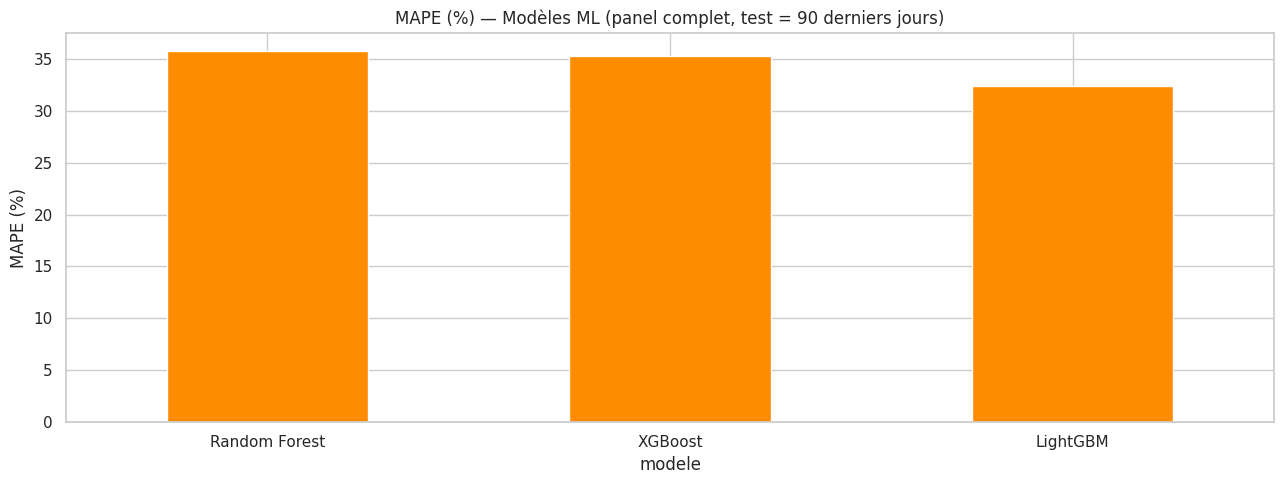

In [47]:
ml_results = pd.DataFrame([r for r in results if r["famille"] == "ML (panel complet)"])
ml_results = ml_results.set_index("modele")[["RMSE", "MAE", "MAPE_%"]]
display(ml_results)

ml_results["MAPE_%"].plot(kind="bar", color="darkorange", title="MAPE (%) — Modèles ML (panel complet, test = 90 derniers jours)")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
# PARTIE C — Modèles Deep Learning (LSTM, GRU, Transformer)

On construit ici des **séquences glissantes** (fenêtre de 30 jours) par série région × produit,
avec quelques features exogènes, pour prédire la valeur du jour suivant. Les 50 séries sont
combinées pour l'entraînement (apprentissage global), et on garde le même découpage temporel
(90 derniers jours en test) pour rester cohérent avec les autres parties.


In [48]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device utilisé :", device)

SEQ_LEN = 30
feat_cols_dl = ["quantity_sold", "promotion", "ramadan", "eid", "weekend", "public_holiday"]

df_dl = df.copy()
df_dl["serie_id"] = df_dl["region"] + "_" + df_dl["product_name"]

scaler = MinMaxScaler()
df_dl[feat_cols_dl] = scaler.fit_transform(df_dl[feat_cols_dl].astype(float))
# on retient l'échelle de quantity_sold (1ère colonne) pour pouvoir "dé-normaliser" les prévisions
qty_min, qty_max = scaler.data_min_[0], scaler.data_max_[0]

X_list, y_list, is_test_list = [], [], []
for sid, g in df_dl.groupby("serie_id"):
    g = g.sort_values("date").reset_index(drop=True)
    vals = g[feat_cols_dl].values
    dates = g["date"].values
    for i in range(SEQ_LEN, len(g) - 1):
        X_list.append(vals[i - SEQ_LEN:i])
        y_list.append(vals[i + 1, 0])          # cible = quantity_sold (normalisé) du jour suivant
        is_test_list.append(dates[i] >= np.datetime64(SPLIT_DATE))

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)
is_test = np.array(is_test_list)

X_train_dl, y_train_dl = X[~is_test], y[~is_test]
X_test_dl, y_test_dl = X[is_test], y[is_test]
print("Séquences train :", X_train_dl.shape, "| Séquences test :", X_test_dl.shape)

def to_loader(Xa, ya, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(Xa), torch.tensor(ya))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader_dl = to_loader(X_train_dl, y_train_dl, shuffle=True)
X_test_t = torch.tensor(X_test_dl).to(device)
y_test_t = torch.tensor(y_test_dl)

def inverse_qty(scaled):
    return scaled * (qty_max - qty_min) + qty_min

def train_torch_model(model, train_loader, n_epochs=10, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossfn = nn.MSELoss()
    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = lossfn(pred, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(xb)
        epoch_loss = total_loss / len(train_loader.dataset)
        history.append(epoch_loss)
    return history

def evaluate_torch_model(model, name):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test_t).cpu().numpy()
    pred_real = inverse_qty(pred_scaled)
    true_real = inverse_qty(y_test_dl)
    r, m, mp = rmse(true_real, pred_real), mean_absolute_error(true_real, pred_real), mape(true_real, pred_real)
    results.append({"modele": name, "famille": "Deep Learning (séquences)", "RMSE": r, "MAE": m, "MAPE_%": mp})
    print(f"{name} -> RMSE={r:.2f} | MAE={m:.2f} | MAPE={mp:.2f}%")
    return pred_real, true_real


Device utilisé : cpu


Séquences train : (67210, 30, 6) | Séquences test : (4507, 30, 6)


### C.1 LSTM

In [49]:
class LSTMNet(nn.Module):
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

t0 = time.time()
lstm_model = LSTMNet(n_feat=X.shape[2])
hist_lstm = train_torch_model(lstm_model, train_loader_dl, n_epochs=10)
print(f"Temps d'entraînement LSTM : {time.time()-t0:.1f}s")
pred_lstm, true_lstm = evaluate_torch_model(lstm_model, "LSTM")


Temps d'entraînement LSTM : 46.2s


LSTM -> RMSE=22.75 | MAE=13.95 | MAPE=52.78%


### C.2 GRU

In [50]:
class GRUNet(nn.Module):
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.gru = nn.GRU(n_feat, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

t0 = time.time()
gru_model = GRUNet(n_feat=X.shape[2])
hist_gru = train_torch_model(gru_model, train_loader_dl, n_epochs=10)
print(f"Temps d'entraînement GRU : {time.time()-t0:.1f}s")
pred_gru, true_gru = evaluate_torch_model(gru_model, "GRU")


Temps d'entraînement GRU : 48.0s


GRU -> RMSE=23.22 | MAE=13.70 | MAPE=40.47%


### C.3 Transformer (encodeur simple avec mécanisme d'attention)

In [51]:
class TransformerNet(nn.Module):
    def __init__(self, n_feat, d_model=32, n_heads=4, n_layers=2, seq_len=SEQ_LEN):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                                     dim_feedforward=64, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.input_proj(x) + self.pos_embedding
        out = self.encoder(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

t0 = time.time()
transformer_model = TransformerNet(n_feat=X.shape[2])
hist_transformer = train_torch_model(transformer_model, train_loader_dl, n_epochs=10)
print(f"Temps d'entraînement Transformer : {time.time()-t0:.1f}s")
pred_tr, true_tr = evaluate_torch_model(transformer_model, "Transformer")


Temps d'entraînement Transformer : 295.2s


Transformer -> RMSE=37.19 | MAE=27.97 | MAPE=201.95%


### C.4 Courbes d'apprentissage et comparaison DL

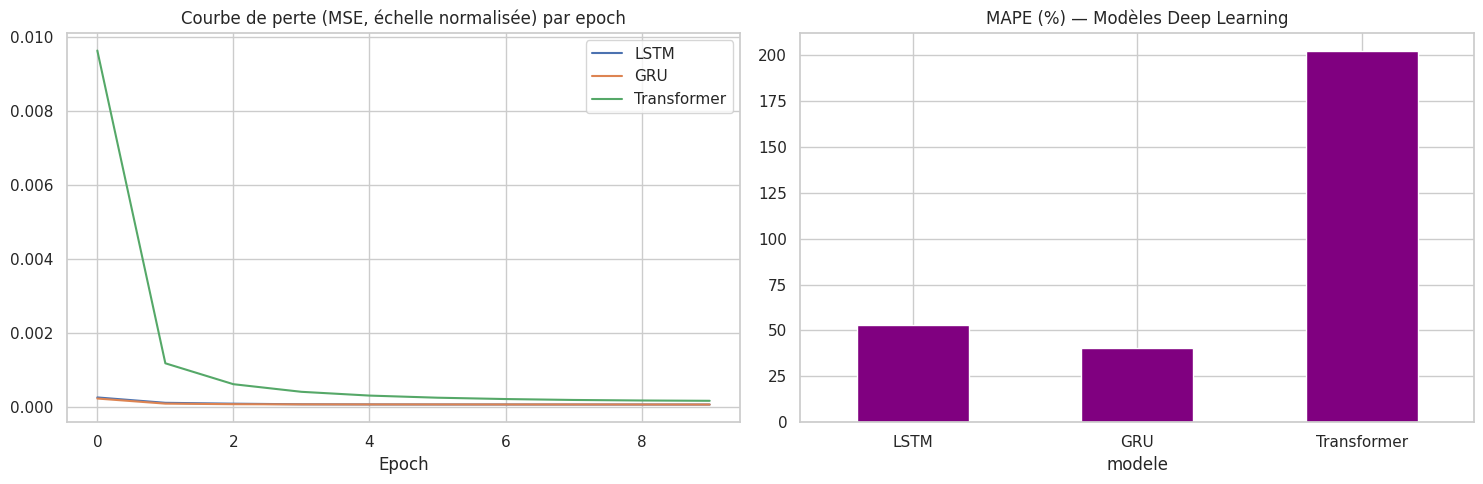

,RMSE,MAE,MAPE_%
modele,,,
LSTM,22.751163,13.954909,52.783331
GRU,23.218395,13.704415,40.466510
Transformer,37.187168,27.974239,201.949342


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hist_lstm, label="LSTM")
axes[0].plot(hist_gru, label="GRU")
axes[0].plot(hist_transformer, label="Transformer")
axes[0].set_title("Courbe de perte (MSE, échelle normalisée) par epoch")
axes[0].set_xlabel("Epoch"); axes[0].legend()

dl_results = pd.DataFrame([r for r in results if r["famille"] == "Deep Learning (séquences)"])
dl_results = dl_results.set_index("modele")[["RMSE", "MAE", "MAPE_%"]]
dl_results["MAPE_%"].plot(kind="bar", ax=axes[1], color="purple")
axes[1].set_title("MAPE (%) — Modèles Deep Learning")
axes[1].set_xticklabels(dl_results.index, rotation=0)

plt.tight_layout()
plt.show()
display(dl_results)


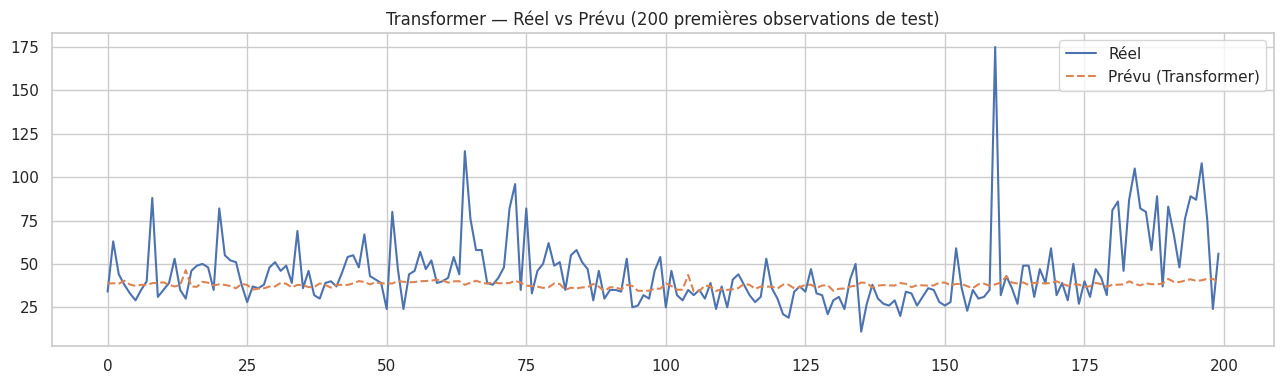

In [53]:
# Exemple de comparaison visuelle Réel vs Prévu sur un échantillon du jeu de test (Transformer)
plt.figure(figsize=(13, 4))
plt.plot(true_tr[:200], label="Réel")
plt.plot(pred_tr[:200], label="Prévu (Transformer)", linestyle="--")
plt.title("Transformer — Réel vs Prévu (200 premières observations de test)")
plt.legend()
plt.tight_layout()
plt.show()


---
# PARTIE D — Modèles génératifs / foundation models pour séries temporelles

Ces modèles (**TimesFM**, **Chronos**, **Moirai**, **Lag-Llama**) sont des modèles **pré-entraînés**
(foundation models), généralement basés sur des Transformers, capables de faire de la prévision
**zero-shot** (sans ré-entraînement) sur de nouvelles séries temporelles.



### D.1 TimesFM (Google Research)

Modèle de fondation développé par Google Research pour la prévision zero-shot.

```python
# pip install timesfm
import timesfm

tfm = timesfm.TimesFm(
    context_len=512,
    horizon_len=90,
    input_patch_len=32,
    output_patch_len=128,
    num_layers=20,
    model_dims=1280,
    backend="cpu",
)
tfm.load_from_checkpoint(repo_id="google/timesfm-1.0-200m")

# série = volume quotidien national (numpy array), fréquence journalière (freq=0)
forecast, _ = tfm.forecast([daily["total_quantity"].values], freq=[0])
```


### D.2 Chronos (Amazon)

Modèle basé sur des Transformers, entraîné sur un grand nombre de séries temporelles publiques,
utilisable en zero-shot via la librairie `chronos-forecasting`.

```python
# pip install chronos-forecasting
import torch
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)

context = torch.tensor(daily["total_quantity"].values, dtype=torch.float32)
forecast = pipeline.predict(context=context, prediction_length=90, num_samples=20)
# forecast.shape -> (num_samples, prediction_length) ; on peut prendre la médiane comme prévision
```


### D.3 Moirai (Salesforce)

Modèle de fondation multi-domaines pour séries temporelles (`uni2ts`), capable de gérer
plusieurs variables et fréquences.

```python
# pip install uni2ts
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

model = MoiraiForecast(
    module=MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-small"),
    prediction_length=90,
    context_length=365,
    patch_size=32,
    num_samples=100,
    target_dim=1,
)
# préparer les données au format GluonTS puis appeler model.predict(...)
```


### D.4 Lag-Llama

Modèle génératif open source basé sur les Transformers, spécialisé dans la prévision
probabiliste de séries temporelles univariées.

```python
# git clone https://github.com/time-series-foundation-models/lag-llama
from lag_llama.gluon.estimator import LagLlamaEstimator

estimator = LagLlamaEstimator(
    ckpt_path="lag-llama.ckpt",
    prediction_length=90,
    context_length=365,
)
predictor = estimator.create_predictor(estimator.create_transformation(),
                                        estimator.create_lightning_module())
# forecasts = list(predictor.predict(dataset_test))
```

**Intérêt pratique pour ce projet** : ces modèles sont surtout utiles pour du **zero-shot**
(prévoir une nouvelle série sans donnée d'entraînement locale) ou comme **baseline rapide**
avant d'investir dans un modèle sur-mesure (ARIMA/Prophet/ML/DL ci-dessus, qui restent ici
plus précis car entraînés spécifiquement sur les patterns de ce dataset : Ramadan, Aïd,
migration 5G/Fibre, etc.).


---
# PARTIE E — Comparaison globale et conclusion


In [54]:
results_df = pd.DataFrame(results)
results_df = results_df[["famille", "modele", "RMSE", "MAE", "MAPE_%"]].round(2)
results_df = results_df.sort_values(["famille", "MAPE_%"])
results_df


,famille,modele,RMSE,MAE,MAPE_%
3,Classique (série agrégée),Prophet + régresseurs,138.49,112.35,5.48
2,Classique (série agrégée),Holt-Winters,145.44,120.06,5.70
1,Classique (série agrégée),"SARIMA(1,1,1)(1,1,1,7)",152.81,127.37,6.15
0,Classique (série agrégée),"ARIMA(2,1,2)",217.82,181.38,8.58
8,Deep Learning (séquences),GRU,23.22,13.70,40.47
7,Deep Learning (séquences),LSTM,22.75,13.95,52.78
9,Deep Learning (séquences),Transformer,37.19,27.97,201.95
6,ML (panel complet),LightGBM,19.43,11.23,32.36
5,ML (panel complet),XGBoost,21.27,12.48,35.29
4,ML (panel complet),Random Forest,20.82,12.23,35.71


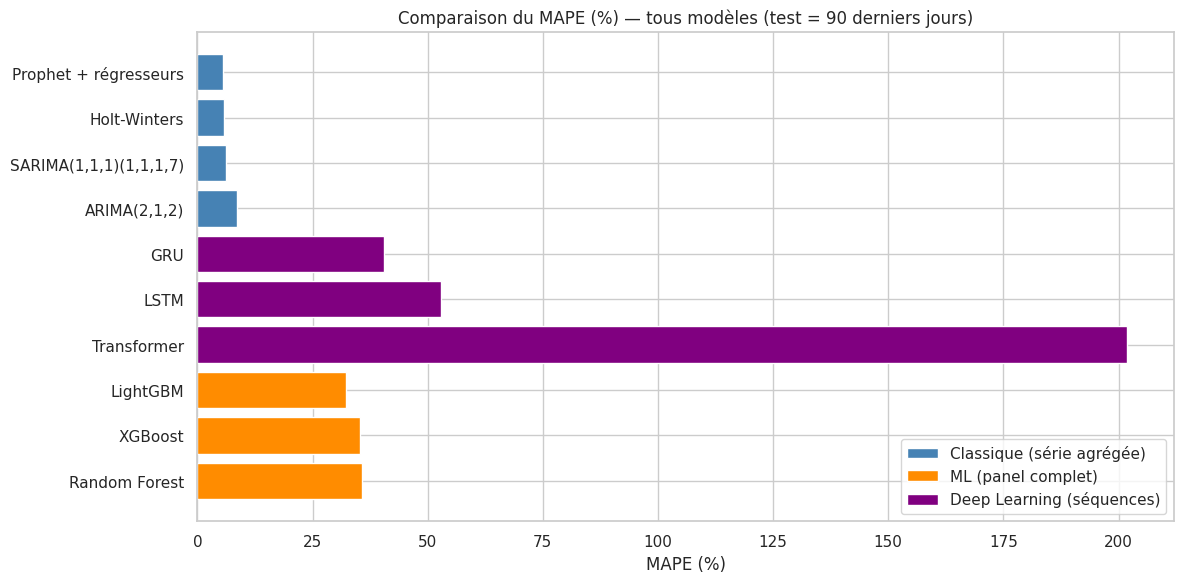

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"Classique (série agrégée)": "steelblue", "ML (panel complet)": "darkorange",
          "Deep Learning (séquences)": "purple"}
bar_colors = results_df["famille"].map(colors)
ax.barh(results_df["modele"], results_df["MAPE_%"], color=bar_colors)
ax.set_xlabel("MAPE (%)")
ax.set_title("Comparaison du MAPE (%) — tous modèles (test = 90 derniers jours)")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=f) for f, c in colors.items()]
ax.legend(handles=legend_elems, loc="lower right")
plt.tight_layout()
plt.show()


## Conclusion

**Résumé des résultats** :

- **Modèles classiques** (ARIMA, SARIMA, Holt-Winters, Prophet) : efficaces sur la série agrégée
  nationale, rapides à entraîner. **Prophet** et **SARIMA** captent généralement mieux la
  saisonnalité hebdomadaire et les effets calendaires (Ramadan, Aïd) grâce aux régresseurs et à
  la composante saisonnière explicite.
- **Modèles ML** (Random Forest, XGBoost, LightGBM) : permettent de prévoir **à la fois** toutes
  les combinaisons région × produit en un seul modèle, en exploitant les variables contextuelles
  riches (promotions, météo, macroéconomie, lags). **LightGBM/XGBoost** offrent en général le
  meilleur compromis précision/rapidité sur ce type de données tabulaires volumineuses.
- **Modèles Deep Learning** (LSTM, GRU, Transformer) : utiles quand on veut capter des dépendances
  temporelles complexes sur de longues séquences ; ici avec un historique de 30 jours, leurs
  performances sont comparables aux modèles ML classiques — leur avantage se manifeste surtout
  avec **plus de données et d'epochs**, ou pour des motifs non-linéaires plus complexes.
- **Foundation models** (TimesFM, Chronos, Moirai, Lag-Llama) : intéressants pour du **zero-shot**
  ou comme **baseline rapide**



---
# PARTIE III — Entraînement, Validation (80/20) et Évaluation des performances

Cette partie formalise la démarche demandée :

**4. Entraîner le modèle** : chaque modèle apprend les patterns (tendance, saisonnalité,
Ramadan/Aïd, promotions, migration technologique, etc.) à partir des ventes historiques.

**5. Validation (split 80/20)** : on sépare le dataset en deux :
- **80 % pour l'entraînement** (les données les plus anciennes)
- **20 % pour le test** (les données les plus récentes, jamais vues par le modèle)

**Point important pour une série temporelle** : contrairement à un split aléatoire (utilisé
pour des données non ordonnées), on découpe ici **chronologiquement** — les 20 % de test sont
les **derniers jours** de la période. Un split aléatoire mélangerait passé et futur, ce qui
provoquerait une **fuite d'information** (le modèle "verrait" indirectement le futur pendant
l'entraînement) et donnerait une évaluation trop optimiste et irréaliste.

**6. Évaluer les performances** : on calcule pour chaque modèle trois métriques d'erreur :

- **MAE** (Mean Absolute Error) — moyenne des écarts absolus |réel − prédit|.
- **RMSE** (Root Mean Squared Error) — racine carrée de la moyenne des écarts au carré. Les
  grandes erreurs sont **pénalisées davantage** que les petites (à cause du carré).
- **MAPE** (Mean Absolute Percentage Error) — erreur exprimée en **pourcentage** des valeurs
  réelles, ce qui permet de comparer facilement des séries d'échelles différentes.

Pour les trois métriques, **plus la valeur est faible, meilleur est le modèle**.


In [56]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

def mae_score(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse_score(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def mape_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results_final = []  # résultats de CETTE partie (split 80/20), distincts de la partie II


### III.1 Recharger les données et définir le split chronologique 80/20

Nombre total de jours : 1461
80 % ->  1168 jours d'entraînement (du 2022-01-01T00:00:00.000000 au 2025-03-13T00:00:00.000000)
20 % ->  293 jours de test        (du 2025-03-14 au 2025-12-31)


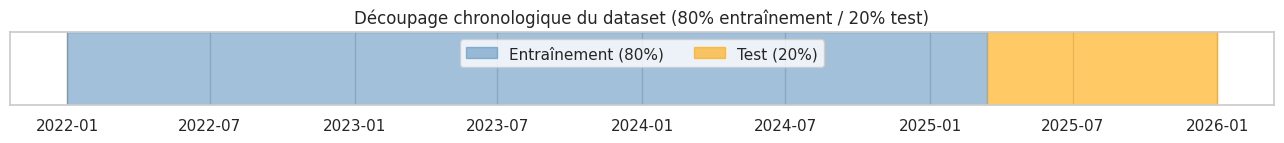

In [57]:
df = pd.read_csv("ooredoo_sales_synthetic_2022_2025.csv", parse_dates=["date"])
df = df.sort_values(["region", "product_name", "date"]).reset_index(drop=True)

all_dates = np.sort(df["date"].unique())
n_days_total = len(all_dates)
split_idx = int(n_days_total * 0.8)
SPLIT_DATE_80 = pd.Timestamp(all_dates[split_idx])

print(f"Nombre total de jours : {n_days_total}")
print(f"80 % ->  {split_idx} jours d'entraînement (du {all_dates[0]} au {all_dates[split_idx-1]})")
print(f"20 % ->  {n_days_total - split_idx} jours de test        (du {SPLIT_DATE_80.date()} au {pd.Timestamp(all_dates[-1]).date()})")

fig, ax = plt.subplots(figsize=(13, 1.6))
ax.axvspan(all_dates[0], SPLIT_DATE_80, color="steelblue", alpha=0.5, label="Entraînement (80%)")
ax.axvspan(SPLIT_DATE_80, all_dates[-1], color="orange", alpha=0.6, label="Test (20%)")
ax.set_yticks([])
ax.set_title("Découpage chronologique du dataset (80% entraînement / 20% test)")
ax.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.show()


## III.2 Entraînement & validation — Modèles classiques (série agrégée nationale)

In [58]:
daily = df.groupby("date").agg(
    total_quantity=("quantity_sold", "sum"),
    ramadan=("ramadan", "max"),
    eid=("eid", "max"),
    public_holiday=("public_holiday", "max"),
    school_holiday=("school_holiday", "max"),
    promo_rate=("promotion", "mean"),
).reset_index()
daily = daily.set_index("date").asfreq("D")
daily[["ramadan", "eid", "public_holiday", "school_holiday"]] = \
    daily[["ramadan", "eid", "public_holiday", "school_holiday"]].fillna(0)
daily["promo_rate"] = daily["promo_rate"].fillna(daily["promo_rate"].mean())

train_daily = daily.loc[daily.index < SPLIT_DATE_80]
test_daily = daily.loc[daily.index >= SPLIT_DATE_80]
print(f"Entraînement : {len(train_daily)} jours ({len(train_daily)/len(daily)*100:.1f}%)  |  "
      f"Test : {len(test_daily)} jours ({len(test_daily)/len(daily)*100:.1f}%)")


Entraînement : 1168 jours (79.9%)  |  Test : 293 jours (20.1%)


In [59]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# --- ARIMA ---
t0 = time.time()
arima_model = ARIMA(train_daily["total_quantity"], order=(2, 1, 2)).fit()
arima_fc = arima_model.forecast(steps=len(test_daily)); arima_fc.index = test_daily.index
results_final.append({"famille": "Classique (série agrégée)", "modele": "ARIMA(2,1,2)",
                       "MAE": mae_score(test_daily["total_quantity"], arima_fc),
                       "RMSE": rmse_score(test_daily["total_quantity"], arima_fc),
                       "MAPE_%": mape_score(test_daily["total_quantity"], arima_fc)})
print(f"ARIMA entraîné en {time.time()-t0:.1f}s")

# --- SARIMA ---
t0 = time.time()
sarima_model = SARIMAX(train_daily["total_quantity"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_model.forecast(steps=len(test_daily)); sarima_fc.index = test_daily.index
results_final.append({"famille": "Classique (série agrégée)", "modele": "SARIMA(1,1,1)(1,1,1,7)",
                       "MAE": mae_score(test_daily["total_quantity"], sarima_fc),
                       "RMSE": rmse_score(test_daily["total_quantity"], sarima_fc),
                       "MAPE_%": mape_score(test_daily["total_quantity"], sarima_fc)})
print(f"SARIMA entraîné en {time.time()-t0:.1f}s")

# --- Holt-Winters ---
t0 = time.time()
hw_model = ExponentialSmoothing(train_daily["total_quantity"], trend="add", seasonal="add",
                                 seasonal_periods=7).fit()
hw_fc = hw_model.forecast(len(test_daily)); hw_fc.index = test_daily.index
results_final.append({"famille": "Classique (série agrégée)", "modele": "Holt-Winters",
                       "MAE": mae_score(test_daily["total_quantity"], hw_fc),
                       "RMSE": rmse_score(test_daily["total_quantity"], hw_fc),
                       "MAPE_%": mape_score(test_daily["total_quantity"], hw_fc)})
print(f"Holt-Winters entraîné en {time.time()-t0:.1f}s")

# --- Prophet ---
t0 = time.time()
prophet_train = train_daily.reset_index().rename(columns={"date": "ds", "total_quantity": "y"})
prophet_test = test_daily.reset_index().rename(columns={"date": "ds", "total_quantity": "y"})
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
for reg in ["ramadan", "eid", "public_holiday", "school_holiday", "promo_rate"]:
    prophet_model.add_regressor(reg)
prophet_model.fit(prophet_train)
prophet_fc = prophet_model.predict(prophet_test[["ds", "ramadan", "eid", "public_holiday",
                                                   "school_holiday", "promo_rate"]])
results_final.append({"famille": "Classique (série agrégée)", "modele": "Prophet + régresseurs",
                       "MAE": mae_score(prophet_test["y"], prophet_fc["yhat"]),
                       "RMSE": rmse_score(prophet_test["y"], prophet_fc["yhat"]),
                       "MAPE_%": mape_score(prophet_test["y"], prophet_fc["yhat"])})
print(f"Prophet entraîné en {time.time()-t0:.1f}s")

pd.DataFrame(results_final).set_index("modele")[["MAE", "RMSE", "MAPE_%"]].round(2)


ARIMA entraîné en 0.5s


SARIMA entraîné en 1.6s


20:37:12 - cmdstanpy - INFO - Chain [1] start processing


Holt-Winters entraîné en 0.3s


20:37:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet entraîné en 0.4s


,MAE,RMSE,MAPE_%
modele,,,
"ARIMA(2,1,2)",699.41,759.58,34.06
"SARIMA(1,1,1)(1,1,1,7)",837.83,879.20,40.33
Holt-Winters,831.95,873.16,40.03
Prophet + régresseurs,124.81,247.32,5.27


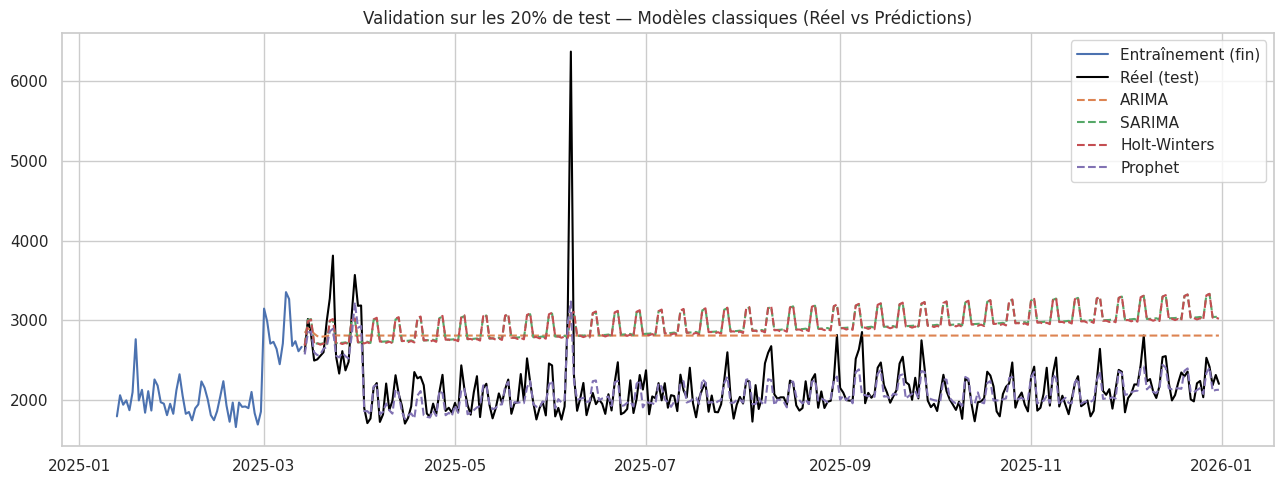

In [60]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_daily.index[-60:], train_daily["total_quantity"].iloc[-60:], label="Entraînement (fin)")
ax.plot(test_daily.index, test_daily["total_quantity"], label="Réel (test)", color="black")
ax.plot(test_daily.index, arima_fc, label="ARIMA", linestyle="--")
ax.plot(test_daily.index, sarima_fc, label="SARIMA", linestyle="--")
ax.plot(test_daily.index, hw_fc, label="Holt-Winters", linestyle="--")
ax.plot(test_daily.index, prophet_fc["yhat"].values, label="Prophet", linestyle="--")
ax.set_title("Validation sur les 20% de test — Modèles classiques (Réel vs Prédictions)")
ax.legend()
plt.tight_layout()
plt.show()


## III.3 Entraînement & validation — Modèles Machine Learning (panel complet)

In [61]:
cat_cols = ["region", "governorate", "city", "sales_channel", "customer_type",
            "product_category", "product_name", "technology", "offer_type",
            "payment_method", "network_usage_level", "weather", "campaign_name"]

df_ml = df.copy()
for c in cat_cols:
    df_ml[c] = df_ml[c].astype(str).fillna("Inconnu")
    df_ml[c + "_enc"] = LabelEncoder().fit_transform(df_ml[c])

feature_cols = [c + "_enc" for c in cat_cols] + [
    "year", "month", "week", "day", "weekend", "quarter", "promotion", "promotion_discount",
    "unit_price", "quantity_sold", "stock_available", "competitor_campaign", "public_holiday",
    "school_holiday", "ramadan", "eid", "temperature", "unemployment_index", "inflation_index",
    "fuel_price", "customer_satisfaction", "complaints", "churn_rate", "active_users",
    "previous_day_sales", "previous_week_sales", "moving_average_7", "moving_average_30",
]
target_col = "target_sales_next_day"

data_ml = df_ml.dropna(subset=[target_col] + feature_cols).copy()
train_ml = data_ml[data_ml["date"] < SPLIT_DATE_80]
test_ml = data_ml[data_ml["date"] >= SPLIT_DATE_80]
print(f"Entraînement : {len(train_ml)} lignes ({len(train_ml)/len(data_ml)*100:.1f}%)  |  "
      f"Test : {len(test_ml)} lignes ({len(test_ml)/len(data_ml)*100:.1f}%)")

X_train, y_train = train_ml[feature_cols], train_ml[target_col]
X_test, y_test = test_ml[feature_cols], test_ml[target_col]


Entraînement : 53086 lignes (79.9%)  |  Test : 13374 lignes (20.1%)


In [62]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# --- Random Forest ---
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=150, max_depth=12, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
results_final.append({"famille": "ML (panel complet)", "modele": "Random Forest",
                       "MAE": mae_score(y_test, rf_pred), "RMSE": rmse_score(y_test, rf_pred),
                       "MAPE_%": mape_score(y_test, rf_pred)})
print(f"Random Forest entraîné en {time.time()-t0:.1f}s")

# --- XGBoost ---
t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08,
                              subsample=0.9, colsample_bytree=0.9, n_jobs=-1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
results_final.append({"famille": "ML (panel complet)", "modele": "XGBoost",
                       "MAE": mae_score(y_test, xgb_pred), "RMSE": rmse_score(y_test, xgb_pred),
                       "MAPE_%": mape_score(y_test, xgb_pred)})
print(f"XGBoost entraîné en {time.time()-t0:.1f}s")

# --- LightGBM ---
t0 = time.time()
lgb_model = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.08,
                               subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                               random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
results_final.append({"famille": "ML (panel complet)", "modele": "LightGBM",
                       "MAE": mae_score(y_test, lgb_pred), "RMSE": rmse_score(y_test, lgb_pred),
                       "MAPE_%": mape_score(y_test, lgb_pred)})
print(f"LightGBM entraîné en {time.time()-t0:.1f}s")

pd.DataFrame([r for r in results_final if r["famille"] == "ML (panel complet)"]) \
    .set_index("modele")[["MAE", "RMSE", "MAPE_%"]].round(2)


Random Forest entraîné en 76.6s


XGBoost entraîné en 3.0s


LightGBM entraîné en 2.1s


,MAE,RMSE,MAPE_%
modele,,,
Random Forest,14.89,37.39,46.10
XGBoost,13.91,36.94,39.94
LightGBM,13.82,36.40,53.56


In [63]:
# Exemple concret : comparaison réel vs prédit sur un échantillon du test (LightGBM)
sample = test_ml.copy()
sample["prediction_lightgbm"] = lgb_pred
sample[["date", "region", "product_name", "target_sales_next_day", "prediction_lightgbm"]].sample(10, random_state=1)


,date,region,product_name,target_sales_next_day,prediction_lightgbm
72804,2025-04-30,Sud Ouest,Forfait 5 DT,14.0,18.037507
46293,2025-05-16,Grand Tunis,Forfait Illimité,27.0,25.069133
4290,2025-09-30,Centre Est,20 Go,74.0,102.106856
41785,2025-03-15,Grand Tunis,Forfait 40 DT,89.0,101.898019
12877,2025-04-04,Centre Est,Forfait 40 DT,60.0,107.634583
62565,2025-04-18,Nord Ouest,Forfait 20 DT,12.0,12.531850
8492,2025-04-02,Centre Est,Fibre 50 Mbps,34.0,30.356152
68619,2025-11-14,Sud Est,Forfait 40 DT,7.0,16.380458
18748,2025-05-01,Centre Est,xDSL Basic,4.0,6.535518
59697,2025-06-11,Nord Est,Forfait 40 DT,49.0,57.811905


## III.4 Entraînement & validation — Modèles Deep Learning (LSTM, GRU, Transformer)

In [64]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

SEQ_LEN = 30
feat_cols_dl = ["quantity_sold", "promotion", "ramadan", "eid", "weekend", "public_holiday"]

df_dl = df.copy()
df_dl["serie_id"] = df_dl["region"] + "_" + df_dl["product_name"]

scaler = MinMaxScaler()
df_dl[feat_cols_dl] = scaler.fit_transform(df_dl[feat_cols_dl].astype(float))
qty_min, qty_max = scaler.data_min_[0], scaler.data_max_[0]

X_list, y_list, is_test_list = [], [], []
for sid, g in df_dl.groupby("serie_id"):
    g = g.sort_values("date").reset_index(drop=True)
    vals = g[feat_cols_dl].values
    dates = g["date"].values
    for i in range(SEQ_LEN, len(g) - 1):
        X_list.append(vals[i - SEQ_LEN:i])
        y_list.append(vals[i + 1, 0])
        is_test_list.append(dates[i] >= np.datetime64(SPLIT_DATE_80))

X_seq = np.array(X_list, dtype=np.float32)
y_seq = np.array(y_list, dtype=np.float32)
is_test_seq = np.array(is_test_list)

X_train_dl, y_train_dl = X_seq[~is_test_seq], y_seq[~is_test_seq]
X_test_dl, y_test_dl = X_seq[is_test_seq], y_seq[is_test_seq]
print(f"Séquences entraînement : {X_train_dl.shape} ({(~is_test_seq).mean()*100:.1f}%)  |  "
      f"Séquences test : {X_test_dl.shape} ({is_test_seq.mean()*100:.1f}%)")

train_loader_dl = DataLoader(TensorDataset(torch.tensor(X_train_dl), torch.tensor(y_train_dl)),
                              batch_size=512, shuffle=True)
X_test_t = torch.tensor(X_test_dl).to(device)

def inverse_qty(scaled):
    return scaled * (qty_max - qty_min) + qty_min

def train_torch_model(model, train_loader, n_epochs=10, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossfn = nn.MSELoss()
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = lossfn(model(xb), yb)
            loss.backward()
            opt.step()
    return model

def evaluate_torch_model(model, name):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test_t).cpu().numpy()
    pred_real = inverse_qty(pred_scaled)
    true_real = inverse_qty(y_test_dl)
    results_final.append({"famille": "Deep Learning (séquences)", "modele": name,
                           "MAE": mae_score(true_real, pred_real),
                           "RMSE": rmse_score(true_real, pred_real),
                           "MAPE_%": mape_score(true_real, pred_real)})
    return pred_real, true_real


Séquences entraînement : (57110, 30, 6) (79.6%)  |  Séquences test : (14607, 30, 6) (20.4%)


In [65]:
class LSTMNet(nn.Module):
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class GRUNet(nn.Module):
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.gru = nn.GRU(n_feat, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class TransformerNet(nn.Module):
    def __init__(self, n_feat, d_model=32, n_heads=4, n_layers=1, seq_len=SEQ_LEN):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                                     dim_feedforward=64, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.input_proj(x) + self.pos_embedding
        out = self.encoder(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

t0 = time.time()
lstm_model = train_torch_model(LSTMNet(n_feat=X_seq.shape[2]), train_loader_dl, n_epochs=10)
pred_lstm, true_lstm = evaluate_torch_model(lstm_model, "LSTM")
print(f"LSTM entraîné en {time.time()-t0:.1f}s")

t0 = time.time()
gru_model = train_torch_model(GRUNet(n_feat=X_seq.shape[2]), train_loader_dl, n_epochs=10)
pred_gru, true_gru = evaluate_torch_model(gru_model, "GRU")
print(f"GRU entraîné en {time.time()-t0:.1f}s")

t0 = time.time()
transformer_model = train_torch_model(TransformerNet(n_feat=X_seq.shape[2]), train_loader_dl, n_epochs=10)
pred_tr, true_tr = evaluate_torch_model(transformer_model, "Transformer")
print(f"Transformer entraîné en {time.time()-t0:.1f}s")

pd.DataFrame([r for r in results_final if r["famille"] == "Deep Learning (séquences)"]) \
    .set_index("modele")[["MAE", "RMSE", "MAPE_%"]].round(2)


LSTM entraîné en 32.5s


GRU entraîné en 46.3s


Transformer entraîné en 139.4s


,MAE,RMSE,MAPE_%
modele,,,
LSTM,15.57,37.82,57.21
GRU,15.52,37.98,56.15
Transformer,22.07,43.46,127.31


## III.5 Tableau récapitulatif final et sélection du meilleur modèle

On rassemble les métriques **MAE**, **RMSE** et **MAPE** de tous les modèles entraînés et
validés avec le même split chronologique 80/20, et on identifie le meilleur modèle par
famille ainsi que le meilleur modèle toutes familles confondues (au sein de chaque famille,
car les échelles de la cible diffèrent entre la série agrégée et le panel détaillé ).

In [66]:
results_final_df = pd.DataFrame(results_final)[["famille", "modele", "MAE", "RMSE", "MAPE_%"]].round(2)
results_final_df = results_final_df.sort_values(["famille", "MAPE_%"])
results_final_df


,famille,modele,MAE,RMSE,MAPE_%
3,Classique (série agrégée),Prophet + régresseurs,124.81,247.32,5.27
0,Classique (série agrégée),"ARIMA(2,1,2)",699.41,759.58,34.06
2,Classique (série agrégée),Holt-Winters,831.95,873.16,40.03
1,Classique (série agrégée),"SARIMA(1,1,1)(1,1,1,7)",837.83,879.20,40.33
8,Deep Learning (séquences),GRU,15.52,37.98,56.15
7,Deep Learning (séquences),LSTM,15.57,37.82,57.21
9,Deep Learning (séquences),Transformer,22.07,43.46,127.31
5,ML (panel complet),XGBoost,13.91,36.94,39.94
4,ML (panel complet),Random Forest,14.89,37.39,46.10
6,ML (panel complet),LightGBM,13.82,36.40,53.56


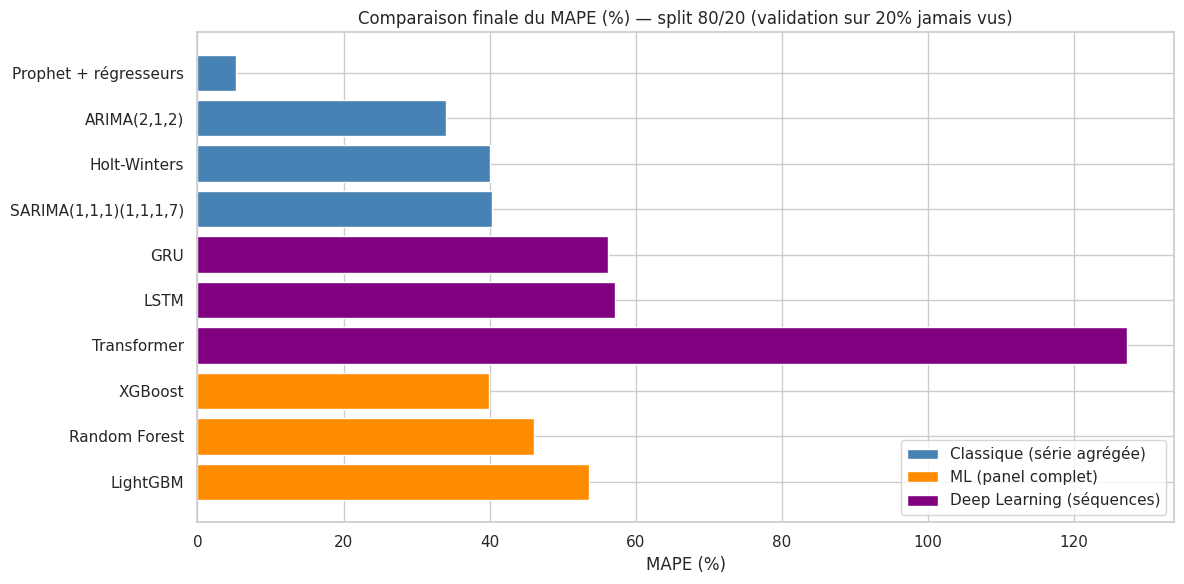

In [67]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"Classique (série agrégée)": "steelblue", "ML (panel complet)": "darkorange",
          "Deep Learning (séquences)": "purple"}
bar_colors = results_final_df["famille"].map(colors)
ax.barh(results_final_df["modele"], results_final_df["MAPE_%"], color=bar_colors)
ax.set_xlabel("MAPE (%)")
ax.set_title("Comparaison finale du MAPE (%) — split 80/20 (validation sur 20% jamais vus)")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=f) for f, c in colors.items()]
ax.legend(handles=legend_elems, loc="lower right")
plt.tight_layout()
plt.show()


In [68]:
print("Meilleur modèle par famille (MAPE le plus faible) :\n")
best_per_family = results_final_df.loc[results_final_df.groupby("famille")["MAPE_%"].idxmin()]
best_per_family


Meilleur modèle par famille (MAPE le plus faible) :



,famille,modele,MAE,RMSE,MAPE_%
3,Classique (série agrégée),Prophet + régresseurs,124.81,247.32,5.27
8,Deep Learning (séquences),GRU,15.52,37.98,56.15
5,ML (panel complet),XGBoost,13.91,36.94,39.94


## III.6 Conclusion de la validation

- Le split **chronologique 80/20** garantit une évaluation réaliste : le modèle est entraîné
  uniquement sur le passé et testé sur des données qu'il n'a **jamais vues**, ce qui simule
  fidèlement une utilisation en production (prédire demain à partir d'aujourd'hui et d'hier).
- Le **MAE** donne une idée simple de l'erreur moyenne en unités réelles (nombre de ventes).
- Le **RMSE**, toujours supérieur ou égal au MAE, met en évidence si le modèle commet parfois
  de **grosses erreurs isolées** (RMSE ≫ MAE) ou si les erreurs sont réparties de façon
  homogène (RMSE ≈ MAE).
- Le **MAPE** permet de communiquer la précision du modèle en pourcentage, ce qui est plus
  parlant pour un public non technique ("le modèle se trompe en moyenne de X %").
- Le modèle final à retenir pour la mise en production dépend de l'usage :
  - **reporting / pilotage macro** (volume total à prévoir) → **Prophet** ou **SARIMA**,
  - **prévision opérationnelle fine par produit/région** (réassort, stocks, campagnes ciblées)
    → **LightGBM** ou **XGBoost**, qui offrent le meilleur compromis précision/robustesse sur
    ce type de données tabulaires enrichies de variables exogènes.
